/tmp/vgarciap/ipykernel_3930498/2532453700.py:21: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  timestamps = [datetime.datetime.utcfromtimestamp(float(t)) for t in times]


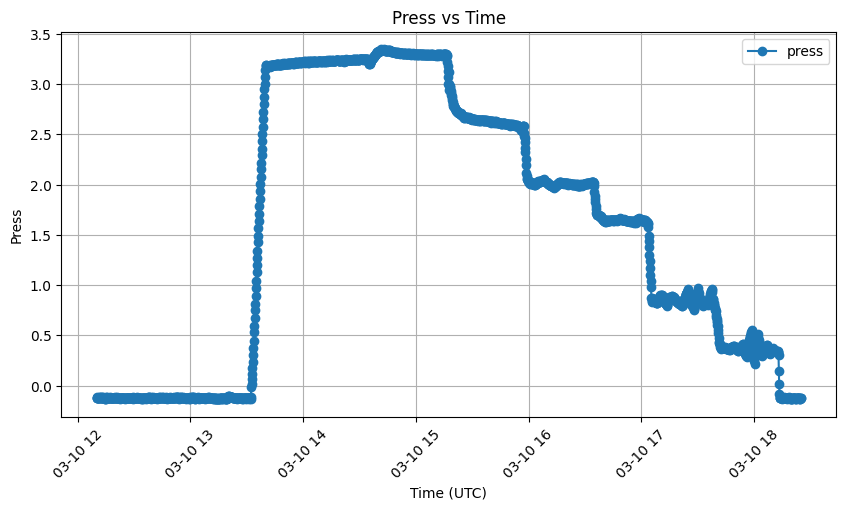

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/resampled20250310.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    tree = file["resampled_data"]  # nombre correcto del árbol
    data = tree.arrays(library="np")  # Devuelve un diccionario de numpy arrays

# Extraer tiempos y valores de wav[0][0]
times = data["t"]
press = data["press"]
temp = data["temp"]


# Convertir tiempos a formato datetime
timestamps = [datetime.datetime.utcfromtimestamp(float(t)) for t in times]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(timestamps, press, marker='o', linestyle='-', label='press')
plt.xlabel("Time (UTC)")
plt.ylabel("Press")
plt.title("Press vs Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


/tmp/vgarciap/ipykernel_3930498/413804866.py:18: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])


PEEK-7 FIBER - FBG WAVELENGTH FILTERING (Automatic μ±3σ method)

FBG-1-P (Polarization: P, Sensor: 1)
  Mean:          1.557809e-06 m  (1.56 μm)
  Std Dev:       1.845121e-10 m  (0.18 nm)
  Threshold Min: 1.557255e-06 m
  Threshold Max: 1.558362e-06 m
  Valid points:  1418 / 2251 (63.0%)
  Discarded:     833 points

FBG-1-S (Polarization: S, Sensor: 1)
  Mean:          1.557812e-06 m  (1.56 μm)
  Std Dev:       1.730241e-10 m  (0.17 nm)
  Threshold Min: 1.557293e-06 m
  Threshold Max: 1.558331e-06 m
  Valid points:  1422 / 2251 (63.2%)
  Discarded:     829 points

FBG-2-P (Polarization: P, Sensor: 2)
  Mean:          1.560889e-06 m  (1.56 μm)
  Std Dev:       1.552328e-10 m  (0.16 nm)
  Threshold Min: 1.560423e-06 m
  Threshold Max: 1.561355e-06 m
  Valid points:  1427 / 2251 (63.4%)
  Discarded:     824 points

FBG-2-S (Polarization: S, Sensor: 2)
  Mean:          1.560887e-06 m  (1.56 μm)
  Std Dev:       1.585559e-10 m  (0.16 nm)
  Threshold Min: 1.560411e-06 m
  Threshold Max: 1.56

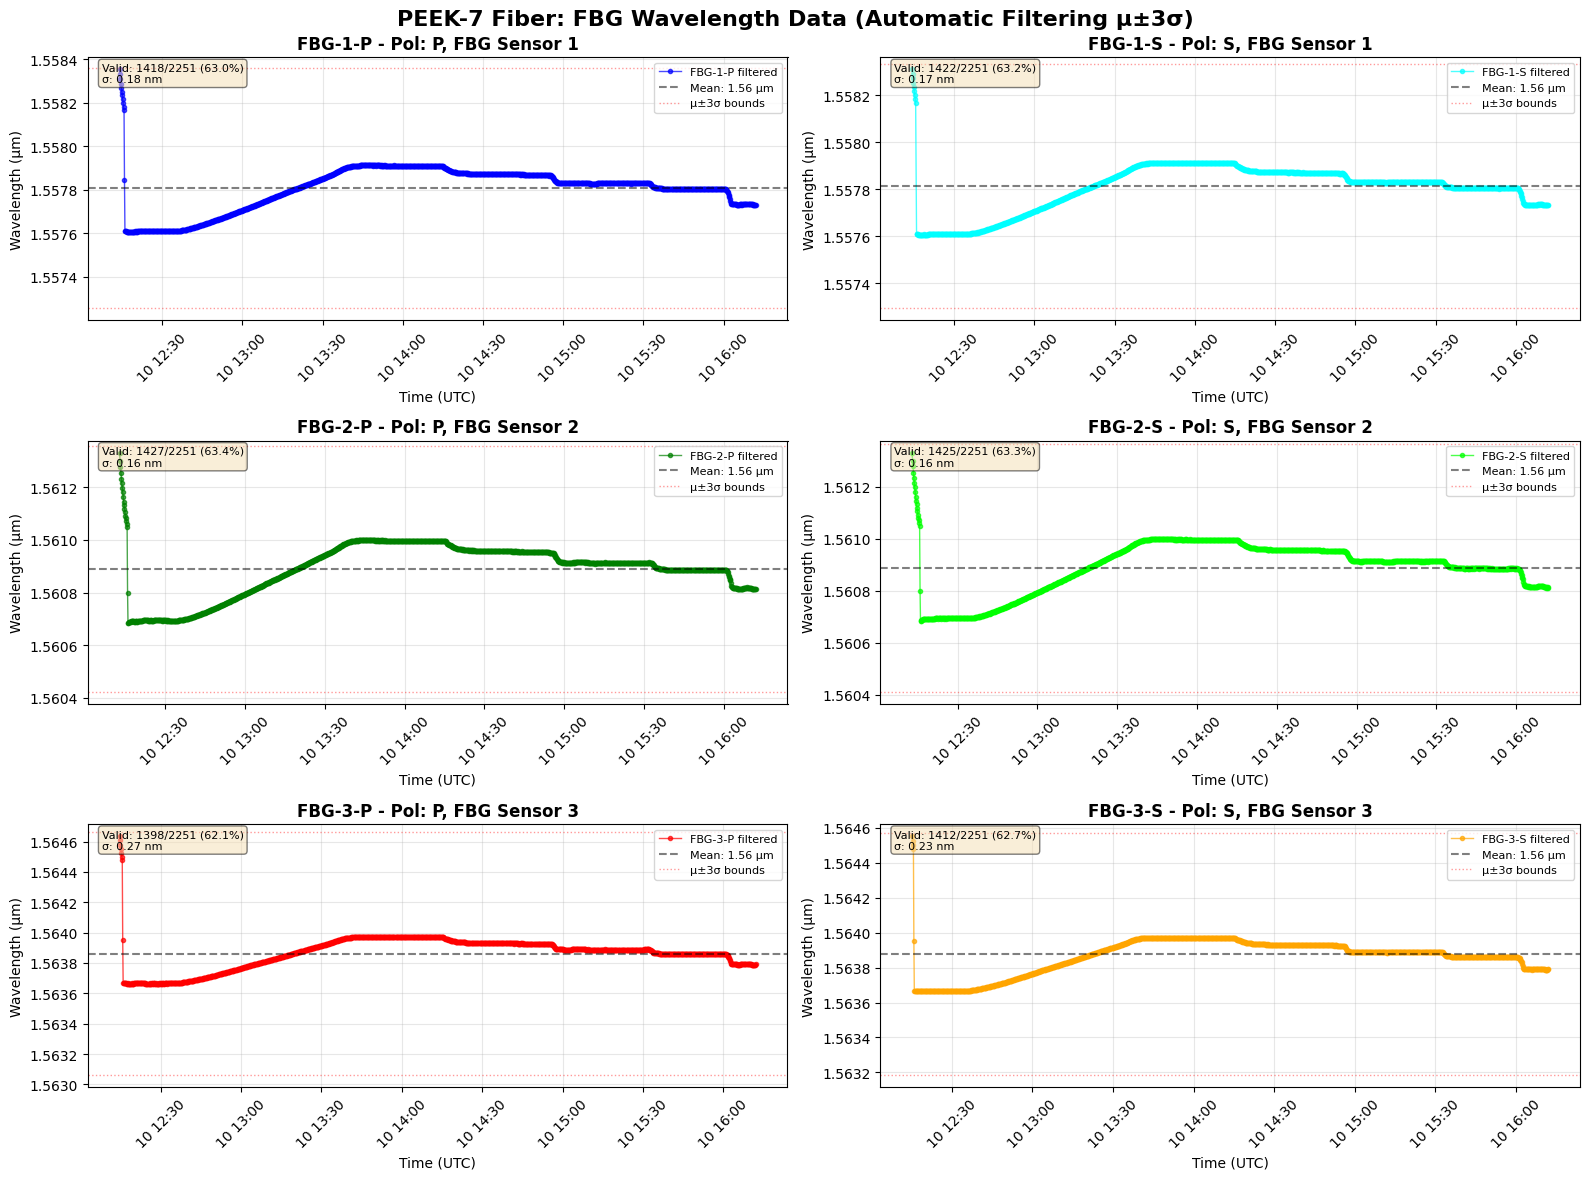


SUMMARY: PEEK-7 Fiber FBG Sensors - Filtered Wavelength Statistics
Sensor     Pol   Mean (μm)    Std (nm)   Valid Points    % Valid   
--------------------------------------------------------------------------------
FBG-1-P    P     1.5578       0.18       1418/2251       63.0      
FBG-1-S    S     1.5578       0.17       1422/2251       63.2      
FBG-2-P    P     1.5609       0.16       1427/2251       63.4      
FBG-2-S    S     1.5609       0.16       1425/2251       63.3      
FBG-3-P    P     1.5639       0.27       1398/2251       62.1      
FBG-3-S    S     1.5639       0.23       1412/2251       62.7      


In [2]:
# ============================================================================
# PEEK-7 Fiber: FBG Wavelength Data Processing with Automatic Outlier Filtering
# ============================================================================
# 3 FBG sensors × 2 polarizations (P, S) = 6 channels total
# Automatic filtering: Removes sentinels (≤0) + outliers (μ±3σ method)

# Configuration: FBG sensors and polarizations
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P", "color": "blue"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S", "color": "cyan"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P", "color": "green"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S", "color": "lime"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P", "color": "red"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S", "color": "orange"},
]

# Convert timestamps once
timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])

# Store filtered data for each sensor
filtered_data = {}

print("=" * 80)
print("PEEK-7 FIBER - FBG WAVELENGTH FILTERING (Automatic μ±3σ method)")
print("=" * 80)

# Process each FBG sensor/polarization
for cfg in fbg_config:
    pol, sensor, label = cfg["pol"], cfg["sensor"], cfg["label"]
    
    # Extract wavelength data
    wav_data = data["wav"][:, pol, sensor]
    
    # Step 1: Filter sentinels and negative values
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Step 2: Calculate automatic thresholds (mean ± 3*std)
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - 3 * std_wav
    threshold_max = mean_wav + 3 * std_wav
    
    # Step 3: Apply complete filter
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    timestamps_filtered = timestamps[mask_filtered]
    wav_filtered = wav_data[mask_filtered]
    
    # Store filtered data
    filtered_data[label] = {
        "timestamps": timestamps_filtered,
        "wavelength": wav_filtered,
        "mean": mean_wav,
        "std": std_wav,
        "threshold_min": threshold_min,
        "threshold_max": threshold_max,
        "n_valid": np.sum(mask_filtered),
        "n_total": len(wav_data)
    }
    
    # Print statistics
    print(f"\n{label} (Polarization: {'P' if pol == 0 else 'S'}, Sensor: {sensor + 1})")
    print(f"  Mean:          {mean_wav:.6e} m  ({mean_wav*1e6:.2f} μm)")
    print(f"  Std Dev:       {std_wav:.6e} m  ({std_wav*1e9:.2f} nm)")
    print(f"  Threshold Min: {threshold_min:.6e} m")
    print(f"  Threshold Max: {threshold_max:.6e} m")
    print(f"  Valid points:  {np.sum(mask_filtered)} / {len(wav_data)} ({100*np.sum(mask_filtered)/len(wav_data):.1f}%)")
    print(f"  Discarded:     {len(wav_data) - np.sum(mask_filtered)} points")

print("\n" + "=" * 80)

# ============================================================================
# VISUALIZATION: Individual plots for each FBG sensor
# ============================================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('PEEK-7 Fiber: FBG Wavelength Data (Automatic Filtering μ±3σ)', 
             fontsize=16, fontweight='bold')

for idx, cfg in enumerate(fbg_config):
    label = cfg["label"]
    color = cfg["color"]
    pol = cfg["pol"]
    sensor = cfg["sensor"]
    
    # Get subplot position
    row = sensor
    col = pol
    ax = axes[row, col]
    
    # Get filtered data
    data_filt = filtered_data[label]
    
    # Plot filtered wavelength data
    ax.plot(data_filt["timestamps"], data_filt["wavelength"] * 1e6, 
            marker='o', markersize=3, linestyle='-', linewidth=1, 
            color=color, alpha=0.7, label=f'{label} filtered')
    
    # Add mean line
    ax.axhline(y=data_filt["mean"] * 1e6, color='black', linestyle='--', 
               linewidth=1.5, alpha=0.5, label=f'Mean: {data_filt["mean"]*1e6:.2f} μm')
    
    # Add ±3σ threshold lines
    ax.axhline(y=data_filt["threshold_min"] * 1e6, color='red', linestyle=':', 
               linewidth=1, alpha=0.4, label='μ±3σ bounds')
    ax.axhline(y=data_filt["threshold_max"] * 1e6, color='red', linestyle=':', 
               linewidth=1, alpha=0.4)
    
    # Formatting
    ax.set_xlabel('Time (UTC)', fontsize=10)
    ax.set_ylabel('Wavelength (μm)', fontsize=10)
    ax.set_title(f'{label} - Pol: {"P" if pol == 0 else "S"}, FBG Sensor {sensor + 1}', 
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Add text box with statistics
    stats_text = f'Valid: {data_filt["n_valid"]}/{data_filt["n_total"]} ({100*data_filt["n_valid"]/data_filt["n_total"]:.1f}%)\nσ: {data_filt["std"]*1e9:.2f} nm'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: PEEK-7 Fiber FBG Sensors - Filtered Wavelength Statistics")
print("=" * 80)
print(f"{'Sensor':<10} {'Pol':<5} {'Mean (μm)':<12} {'Std (nm)':<10} {'Valid Points':<15} {'% Valid':<10}")
print("-" * 80)

for cfg in fbg_config:
    label = cfg["label"]
    pol = "P" if cfg["pol"] == 0 else "S"
    data_filt = filtered_data[label]
    
    print(f"{label:<10} {pol:<5} {data_filt['mean']*1e6:<12.4f} {data_filt['std']*1e9:<10.2f} "
          f"{data_filt['n_valid']}/{data_filt['n_total']:<10} "
          f"{100*data_filt['n_valid']/data_filt['n_total']:<10.1f}")

print("=" * 80)


Invalid data filter (≤ 0):
  Valid points:   2249 / 2251 (99.9%)
  Removed points: 2 (sentinels, zeros, negatives)

No time filter applied - showing all valid data points

RTD TEMPERATURE SENSORS - PEEK-7 Fiber Setup
RTD-1 (External): Mean= 86.77K, Std=21.805K, Range=[76.28, 294.22]K
RTD-2 (External): Mean= 89.97K, Std=22.485K, Range=[76.21, 294.22]K
RTD-3 (External): Mean=105.17K, Std=29.766K, Range=[76.07, 294.22]K
RTD-4 (External): Mean= 94.11K, Std=24.382K, Range=[76.10, 294.27]K
RTD-7 (Internal): Mean=117.25K, Std=74.391K, Range=[76.36, 294.99]K
RTD-8 (Internal): Mean=117.76K, Std=74.274K, Range=[76.88, 294.97]K


/tmp/vgarciap/ipykernel_3930498/2874591868.py:11: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])


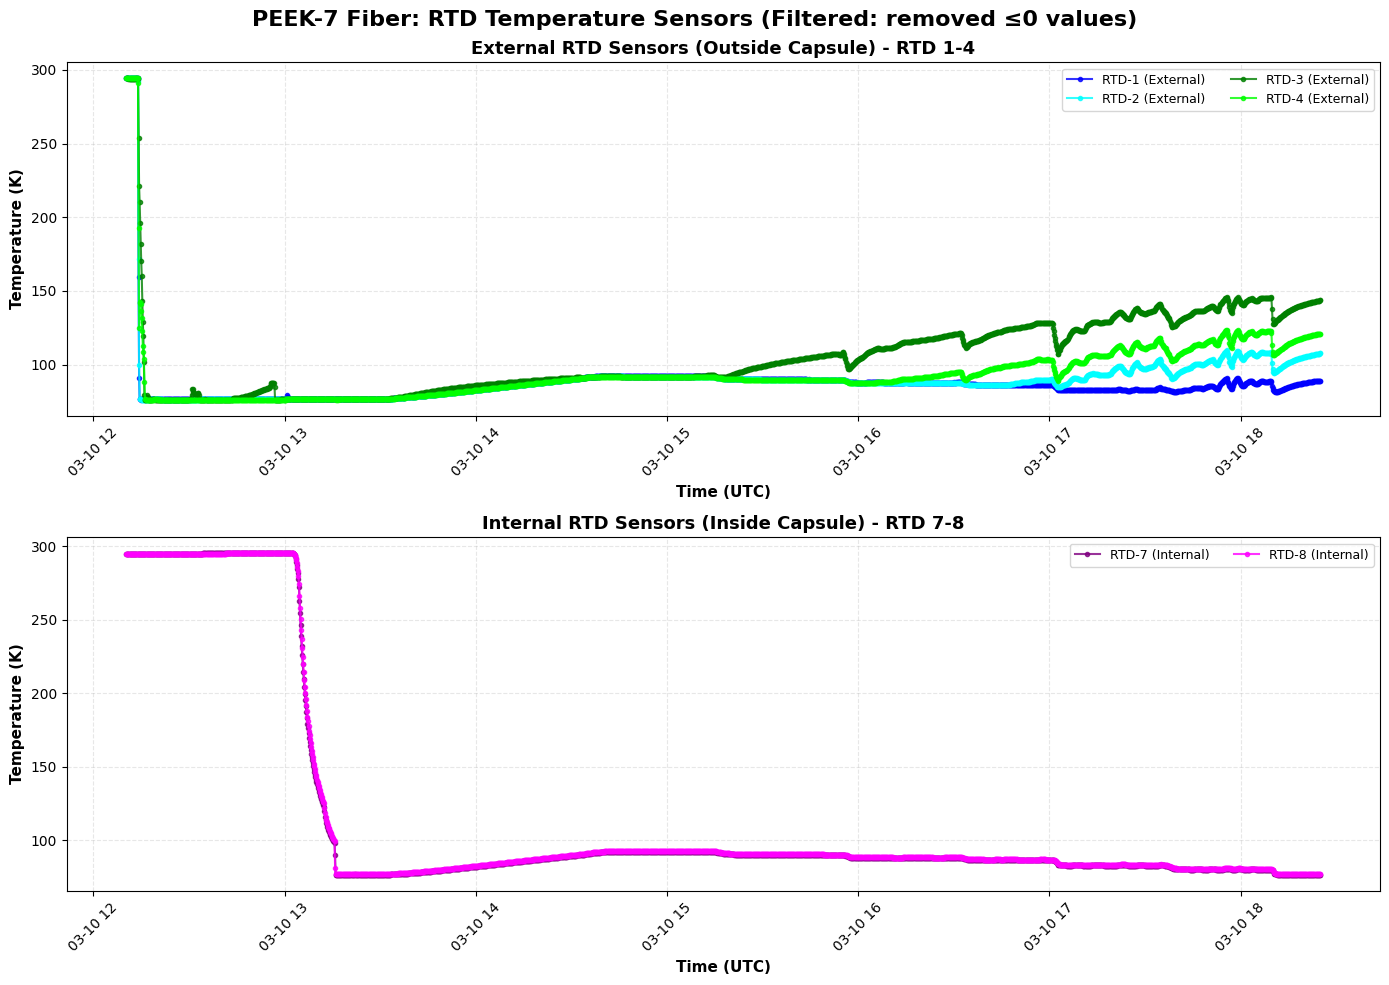

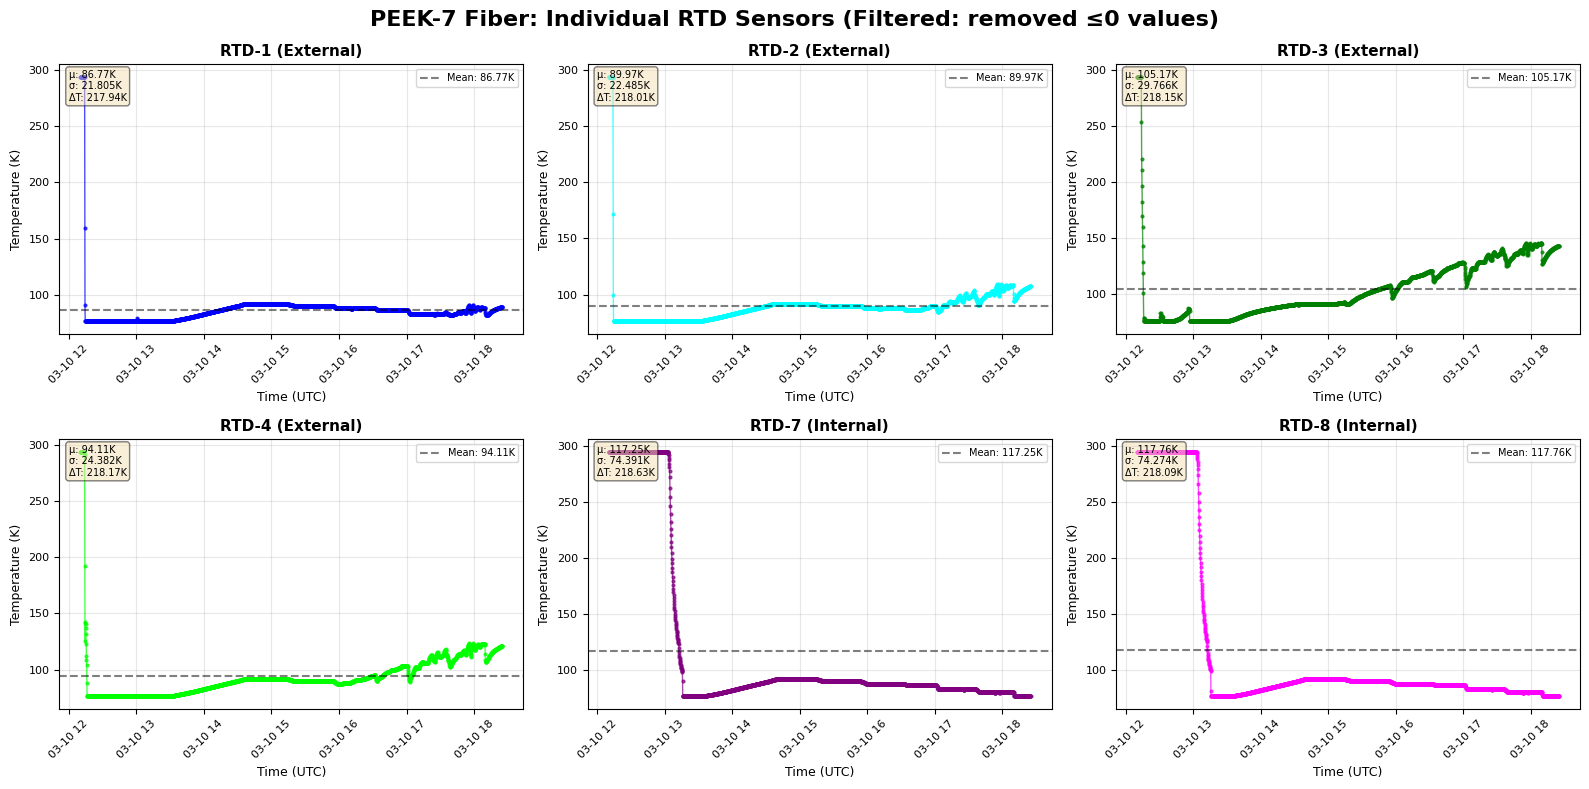

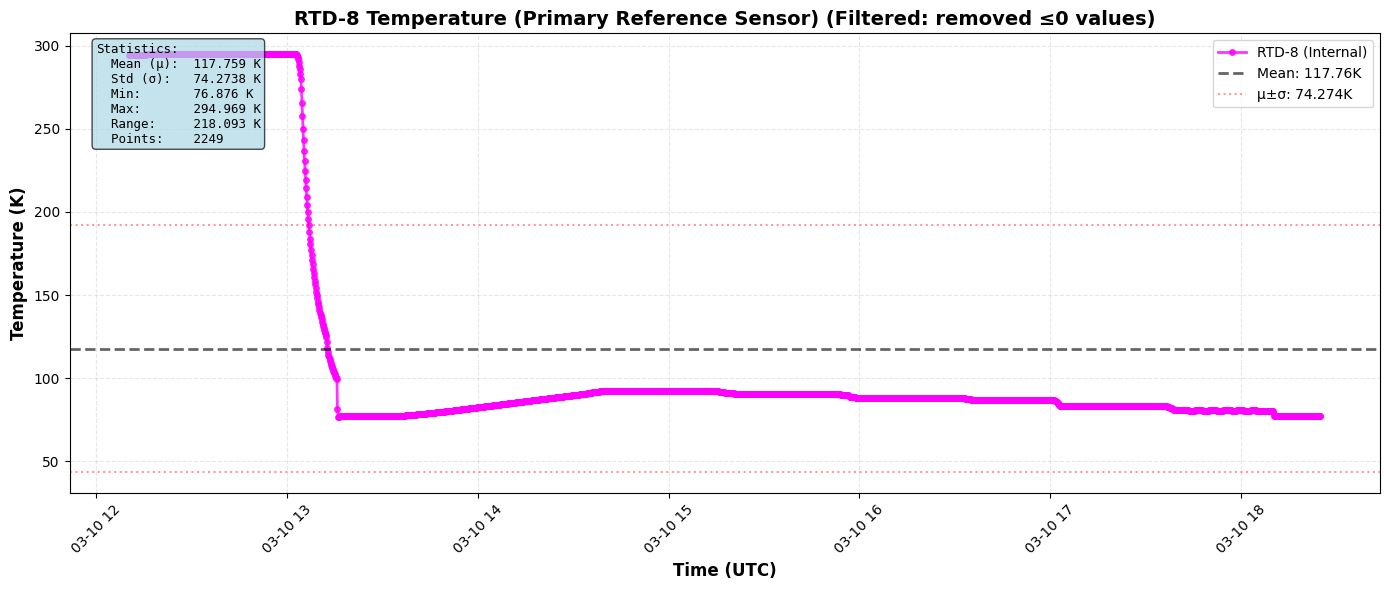


✅ RTD temperature visualization complete!


In [3]:
# ============================================================================
# RTD Temperature Sensors - PEEK-7 Fiber Pressure Setup
# ============================================================================
# 8 RTD sensors total:
#   - RTD 1-4: External sensors (outside capsule) - Active
#   - RTD 5-6: Not connected / No valid readings
#   - RTD 7-8: Internal sensors (inside capsule) - Active
# Time filtering can be applied for specific experiment phases

# Convert timestamps
timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])

# Configuration: RTD sensors
# RTD 1-4: External sensors (outside capsule) - Active
# RTD 5-6: Not connected / No valid readings
# RTD 7-8: Internal sensors (inside capsule) - Active
rtd_config = [
    {"id": 0, "label": "RTD-1", "location": "External", "color": "blue"},
    {"id": 1, "label": "RTD-2", "location": "External", "color": "cyan"},
    {"id": 2, "label": "RTD-3", "location": "External", "color": "green"},
    {"id": 3, "label": "RTD-4", "location": "External", "color": "lime"},
    {"id": 6, "label": "RTD-7", "location": "Internal", "color": "purple"},
    {"id": 7, "label": "RTD-8", "location": "Internal", "color": "magenta"},
]

# RTD sensors not connected (excluded from analysis)
rtd_inactive = [
    {"id": 4, "label": "RTD-5", "location": "Not connected", "color": "lightgray"},
    {"id": 5, "label": "RTD-6", "location": "Not connected", "color": "darkgray"},
]

# Step 1: Filter out invalid values (sentinels ≤ 0) from ALL RTD sensors
# Create a mask that is True only when ALL sensors have valid (positive) values
mask_valid = np.all(temp > 0, axis=1)
timestamps_valid = timestamps[mask_valid]
temp_valid = temp[mask_valid]

n_invalid = len(timestamps) - np.sum(mask_valid)
print(f"Invalid data filter (≤ 0):")
print(f"  Valid points:   {np.sum(mask_valid)} / {len(timestamps)} ({100*np.sum(mask_valid)/len(timestamps):.1f}%)")
print(f"  Removed points: {n_invalid} (sentinels, zeros, negatives)")

# Step 2: Optional time filter (set to None to disable, or datetime.time(hour, minute) to enable)
time_filter = None  # Change to datetime.time(14, 0) to filter data >= 14:00 UTC
# time_filter = datetime.time(13, 46)  # Example: filter >= 13:46 UTC

# Apply time filter if specified
if time_filter is not None:
    mask_time = np.array([t.time() >= time_filter for t in timestamps_valid])
    timestamps_filtered = timestamps_valid[mask_time]
    temp_filtered = temp_valid[mask_time]
    filter_label = f" (≥ {time_filter.strftime('%H:%M')} UTC, filtered)"
    print(f"\nTime filter applied: Data from {time_filter.strftime('%H:%M')} UTC onwards")
    print(f"  Points after time filter: {len(timestamps_filtered)} / {len(timestamps_valid)} ({100*len(timestamps_filtered)/len(timestamps_valid):.1f}%)")
else:
    timestamps_filtered = timestamps_valid
    temp_filtered = temp_valid
    filter_label = " (Filtered: removed ≤0 values)"
    print("\nNo time filter applied - showing all valid data points")

print("\n" + "=" * 80)
print("RTD TEMPERATURE SENSORS - PEEK-7 Fiber Setup")
print("=" * 80)

# Calculate statistics for each sensor
for cfg in rtd_config:
    sensor_id = cfg["id"]
    temp_data = temp_filtered[:, sensor_id]
    
    mean_temp = np.mean(temp_data)
    std_temp = np.std(temp_data)
    min_temp = np.min(temp_data)
    max_temp = np.max(temp_data)
    
    print(f"{cfg['label']} ({cfg['location']:<8}): "
          f"Mean={mean_temp:>6.2f}K, Std={std_temp:>5.3f}K, "
          f"Range=[{min_temp:.2f}, {max_temp:.2f}]K")

print("=" * 80)

# ============================================================================
# VISUALIZATION 1: All RTD sensors overview
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'PEEK-7 Fiber: RTD Temperature Sensors{filter_label}', 
             fontsize=16, fontweight='bold')

# Subplot 1: External sensors (RTD 1-4)
for cfg in rtd_config[:4]:  # First 4 sensors are external
    sensor_id = cfg["id"]
    ax1.plot(timestamps_filtered, temp_filtered[:, sensor_id], 
             marker='o', markersize=3, linestyle='-', linewidth=1.5,
             color=cfg["color"], alpha=0.8, label=f'{cfg["label"]} ({cfg["location"]})')

ax1.set_xlabel('Time (UTC)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
ax1.set_title('External RTD Sensors (Outside Capsule) - RTD 1-4', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='best', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3, linestyle='--')

# Subplot 2: Internal sensors (RTD 7-8)
for cfg in rtd_config[4:]:  # Last 2 sensors are internal
    sensor_id = cfg["id"]
    ax2.plot(timestamps_filtered, temp_filtered[:, sensor_id], 
             marker='o', markersize=3, linestyle='-', linewidth=1.5,
             color=cfg["color"], alpha=0.8, label=f'{cfg["label"]} ({cfg["location"]})')

ax2.set_xlabel('Time (UTC)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
ax2.set_title('Internal RTD Sensors (Inside Capsule) - RTD 7-8', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='best', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Individual plots for each RTD sensor (2x3 grid)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'PEEK-7 Fiber: Individual RTD Sensors{filter_label}', 
             fontsize=16, fontweight='bold')

for idx, cfg in enumerate(rtd_config):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    sensor_id = cfg["id"]
    temp_data = temp_filtered[:, sensor_id]
    
    # Plot temperature
    ax.plot(timestamps_filtered, temp_data, 
            marker='o', markersize=2, linestyle='-', linewidth=1,
            color=cfg["color"], alpha=0.7)
    
    # Add mean line
    mean_temp = np.mean(temp_data)
    ax.axhline(y=mean_temp, color='black', linestyle='--', 
               linewidth=1.5, alpha=0.5, label=f'Mean: {mean_temp:.2f}K')
    
    # Formatting
    ax.set_xlabel('Time (UTC)', fontsize=9)
    ax.set_ylabel('Temperature (K)', fontsize=9)
    ax.set_title(f'{cfg["label"]} ({cfg["location"]})', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text box
    std_temp = np.std(temp_data)
    stats_text = f'μ: {mean_temp:.2f}K\nσ: {std_temp:.3f}K\nΔT: {np.max(temp_data)-np.min(temp_data):.2f}K'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: Focus on RTD-8 (Primary reference sensor)
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# RTD-8 is typically used as reference (index 7)
sensor_id = 7
temp_data = temp_filtered[:, sensor_id]
mean_temp = np.mean(temp_data)
std_temp = np.std(temp_data)

ax.plot(timestamps_filtered, temp_data, 
        marker='o', markersize=4, linestyle='-', linewidth=2,
        color='magenta', alpha=0.8, label='RTD-8 (Internal)')

# Add mean and ±1σ bands
ax.axhline(y=mean_temp, color='black', linestyle='--', 
           linewidth=2, alpha=0.6, label=f'Mean: {mean_temp:.2f}K')
ax.axhline(y=mean_temp + std_temp, color='red', linestyle=':', 
           linewidth=1.5, alpha=0.4, label=f'μ±σ: {std_temp:.3f}K')
ax.axhline(y=mean_temp - std_temp, color='red', linestyle=':', 
           linewidth=1.5, alpha=0.4)

ax.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperature (K)', fontsize=12, fontweight='bold')
ax.set_title(f'RTD-8 Temperature (Primary Reference Sensor){filter_label}', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Add comprehensive statistics box
stats_text = (f'Statistics:\n'
              f'  Mean (μ):  {mean_temp:.3f} K\n'
              f'  Std (σ):   {std_temp:.4f} K\n'
              f'  Min:       {np.min(temp_data):.3f} K\n'
              f'  Max:       {np.max(temp_data):.3f} K\n'
              f'  Range:     {np.max(temp_data)-np.min(temp_data):.3f} K\n'
              f'  Points:    {len(temp_data)}')
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=9, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✅ RTD temperature visualization complete!")


TEMPORAL WINDOW ANALYSIS: 13:30 - 16:00 UTC

RTD-7 (Internal Sensor):
  Total points in window: 900
  Mean temperature: 87.235 K
  Std deviation: 4.9610 K
  Temperature range: [76.498, 91.896] K

FBG-1-P (FBG Sensor 1, Polarization P):
  Total points in window: 893
  Mean wavelength: 1.557861e-06 m  (1.5579 μm)
  Std deviation: 3.843515e-11 m  (0.04 nm)
  Wavelength range: [1.5578, 1.5579] μm


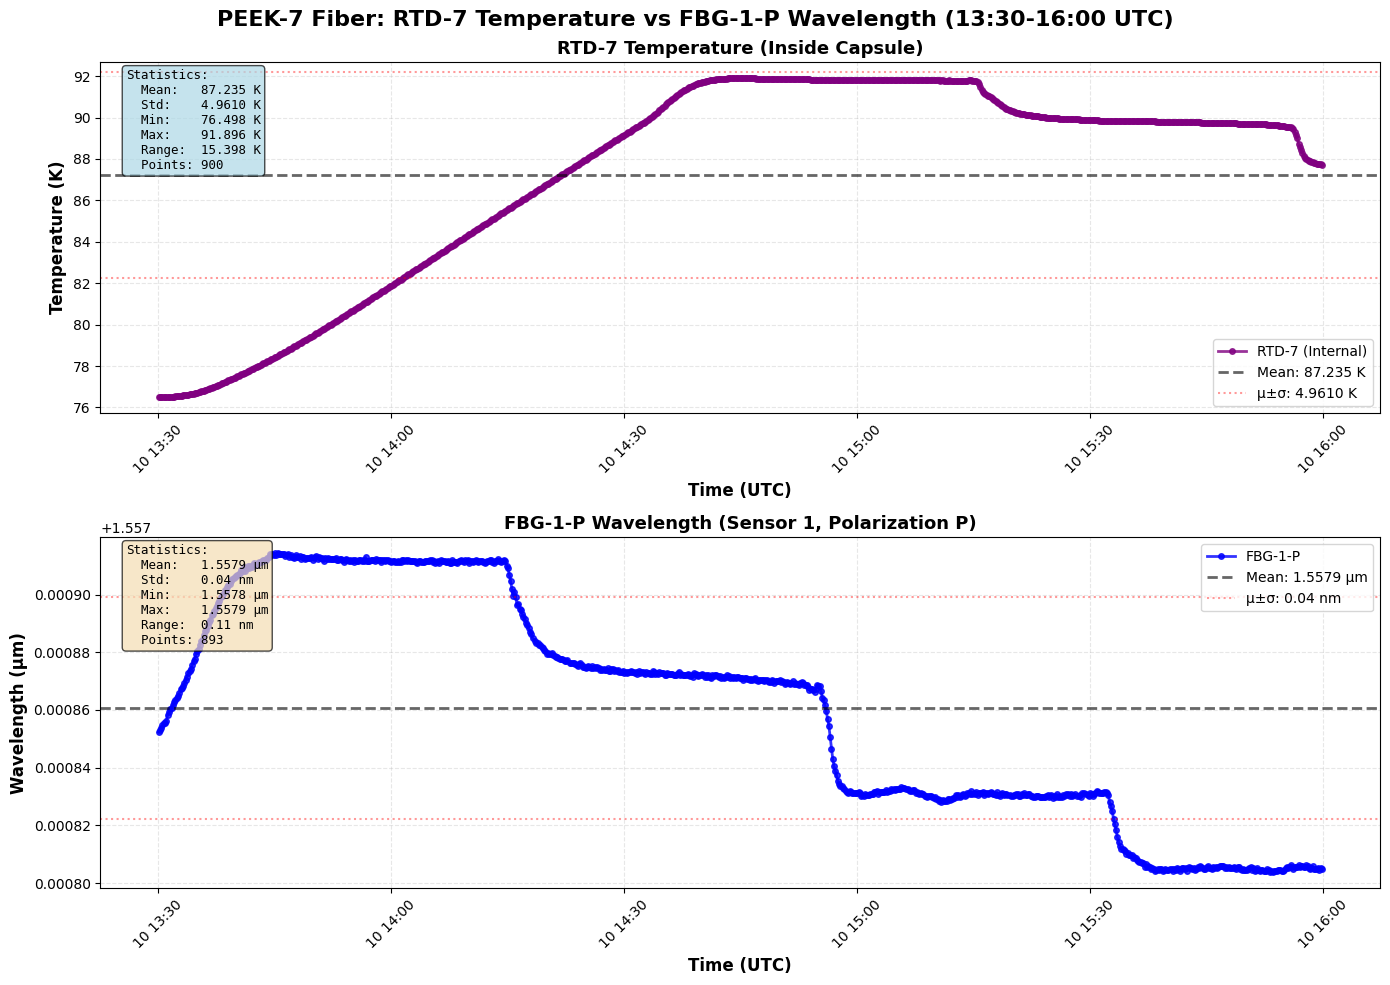

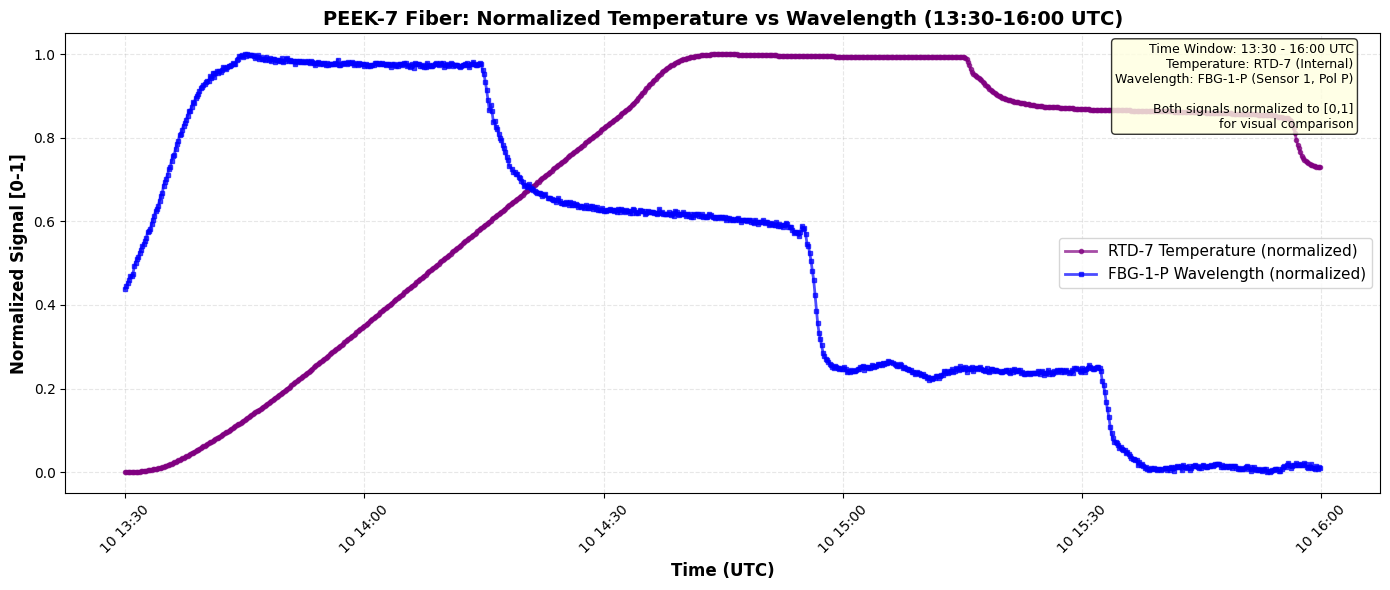


✅ Temporal window analysis (13:30-16:00 UTC) complete!


In [4]:
# ============================================================================
# Temporal Analysis: RTD-7 (Internal) vs FBG-1-P Wavelength (13:30-16:00 UTC)
# ============================================================================
# Focus on experiment window: 13:30 to 16:00 UTC
# RTD-7: Internal temperature sensor (inside capsule)
# FBG-1-P: First FBG sensor, Polarization P

import datetime

# Define time window
time_start = datetime.time(13, 30)  # 13:30 UTC
time_end = datetime.time(16, 0)    # 16:00 UTC

print("=" * 80)
print("TEMPORAL WINDOW ANALYSIS: 13:30 - 16:00 UTC")
print("=" * 80)

# ============================================================================
# Temperature: RTD-7 (sensor index 6)
# ============================================================================

# Use already filtered temperature data from previous cell
sensor_id_temp = 6  # RTD-7 (index 6)

# Apply time window filter
mask_time_temp = np.array([time_start <= t.time() <= time_end for t in timestamps_filtered])
timestamps_window_temp = timestamps_filtered[mask_time_temp]
temp_window = temp_filtered[mask_time_temp, sensor_id_temp]

print(f"\nRTD-7 (Internal Sensor):")
print(f"  Total points in window: {len(temp_window)}")
print(f"  Mean temperature: {np.mean(temp_window):.3f} K")
print(f"  Std deviation: {np.std(temp_window):.4f} K")
print(f"  Temperature range: [{np.min(temp_window):.3f}, {np.max(temp_window):.3f}] K")

# ============================================================================
# Wavelength: FBG-1-P (sensor 0, polarization 0)
# ============================================================================

# Use already filtered wavelength data from previous cell
label_wav = "FBG-1-P"
wav_data_filtered = filtered_data[label_wav]

# Apply time window filter to wavelength
mask_time_wav = np.array([time_start <= t.time() <= time_end for t in wav_data_filtered["timestamps"]])
timestamps_window_wav = wav_data_filtered["timestamps"][mask_time_wav]
wav_window = wav_data_filtered["wavelength"][mask_time_wav]

print(f"\n{label_wav} (FBG Sensor 1, Polarization P):")
print(f"  Total points in window: {len(wav_window)}")
print(f"  Mean wavelength: {np.mean(wav_window):.6e} m  ({np.mean(wav_window)*1e6:.4f} μm)")
print(f"  Std deviation: {np.std(wav_window):.6e} m  ({np.std(wav_window)*1e9:.2f} nm)")
print(f"  Wavelength range: [{np.min(wav_window)*1e6:.4f}, {np.max(wav_window)*1e6:.4f}] μm")

print("=" * 80)

# ============================================================================
# VISUALIZATION: Dual plot (Temperature + Wavelength)
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
fig.suptitle('PEEK-7 Fiber: RTD-7 Temperature vs FBG-1-P Wavelength (13:30-16:00 UTC)', 
             fontsize=16, fontweight='bold')

# ============================================================================
# Subplot 1: RTD-7 Temperature
# ============================================================================

ax1.plot(timestamps_window_temp, temp_window, 
         marker='o', markersize=4, linestyle='-', linewidth=2,
         color='purple', alpha=0.8, label='RTD-7 (Internal)')

# Add mean line
mean_temp = np.mean(temp_window)
ax1.axhline(y=mean_temp, color='black', linestyle='--', 
            linewidth=2, alpha=0.6, label=f'Mean: {mean_temp:.3f} K')

# Add ±1σ bands
std_temp = np.std(temp_window)
ax1.axhline(y=mean_temp + std_temp, color='red', linestyle=':', 
            linewidth=1.5, alpha=0.4, label=f'μ±σ: {std_temp:.4f} K')
ax1.axhline(y=mean_temp - std_temp, color='red', linestyle=':', 
            linewidth=1.5, alpha=0.4)

ax1.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Temperature (K)', fontsize=12, fontweight='bold')
ax1.set_title('RTD-7 Temperature (Inside Capsule)', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Add statistics box
stats_text_temp = (f'Statistics:\n'
                   f'  Mean:   {mean_temp:.3f} K\n'
                   f'  Std:    {std_temp:.4f} K\n'
                   f'  Min:    {np.min(temp_window):.3f} K\n'
                   f'  Max:    {np.max(temp_window):.3f} K\n'
                   f'  Range:  {np.max(temp_window)-np.min(temp_window):.3f} K\n'
                   f'  Points: {len(temp_window)}')
ax1.text(0.02, 0.98, stats_text_temp, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ============================================================================
# Subplot 2: FBG-1-P Wavelength
# ============================================================================

ax2.plot(timestamps_window_wav, wav_window * 1e6, 
         marker='o', markersize=4, linestyle='-', linewidth=2,
         color='blue', alpha=0.8, label='FBG-1-P')

# Add mean line
mean_wav = np.mean(wav_window)
ax2.axhline(y=mean_wav * 1e6, color='black', linestyle='--', 
            linewidth=2, alpha=0.6, label=f'Mean: {mean_wav*1e6:.4f} μm')

# Add ±1σ bands
std_wav = np.std(wav_window)
ax2.axhline(y=(mean_wav + std_wav) * 1e6, color='red', linestyle=':', 
            linewidth=1.5, alpha=0.4, label=f'μ±σ: {std_wav*1e9:.2f} nm')
ax2.axhline(y=(mean_wav - std_wav) * 1e6, color='red', linestyle=':', 
            linewidth=1.5, alpha=0.4)

ax2.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wavelength (μm)', fontsize=12, fontweight='bold')
ax2.set_title('FBG-1-P Wavelength (Sensor 1, Polarization P)', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

# Add statistics box
stats_text_wav = (f'Statistics:\n'
                  f'  Mean:   {mean_wav*1e6:.4f} μm\n'
                  f'  Std:    {std_wav*1e9:.2f} nm\n'
                  f'  Min:    {np.min(wav_window)*1e6:.4f} μm\n'
                  f'  Max:    {np.max(wav_window)*1e6:.4f} μm\n'
                  f'  Range:  {(np.max(wav_window)-np.min(wav_window))*1e9:.2f} nm\n'
                  f'  Points: {len(wav_window)}')
ax2.text(0.02, 0.98, stats_text_wav, transform=ax2.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Overlay plot (normalized for comparison)
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Normalize both signals to [0, 1] for visual comparison
temp_norm = (temp_window - np.min(temp_window)) / (np.max(temp_window) - np.min(temp_window))
wav_norm = (wav_window - np.min(wav_window)) / (np.max(wav_window) - np.min(wav_window))

# Plot normalized signals
ax.plot(timestamps_window_temp, temp_norm, 
        marker='o', markersize=3, linestyle='-', linewidth=2,
        color='purple', alpha=0.7, label='RTD-7 Temperature (normalized)')
ax.plot(timestamps_window_wav, wav_norm, 
        marker='s', markersize=3, linestyle='-', linewidth=2,
        color='blue', alpha=0.7, label='FBG-1-P Wavelength (normalized)')

ax.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Signal [0-1]', fontsize=12, fontweight='bold')
ax.set_title('PEEK-7 Fiber: Normalized Temperature vs Wavelength (13:30-16:00 UTC)', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Add info box
info_text = (f'Time Window: 13:30 - 16:00 UTC\n'
             f'Temperature: RTD-7 (Internal)\n'
             f'Wavelength: FBG-1-P (Sensor 1, Pol P)\n'
             f'\nBoth signals normalized to [0,1]\n'
             f'for visual comparison')
ax.text(0.98, 0.98, info_text, transform=ax.transAxes, 
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n✅ Temporal window analysis (13:30-16:00 UTC) complete!")


TEMPORAL SHIFT: Adding +1 hour to FBG Wavelength Timestamps

FBG-1-P - Time Shift Applied:
  Original first timestamp:  2025-03-10 12:14:01
  Shifted first timestamp:   2025-03-10 13:14:01
  Time difference: +1:00:00
  Original last timestamp:   2025-03-10 16:12:01
  Shifted last timestamp:    2025-03-10 17:12:01

✅ Time shift (+1 hour) applied to all FBG sensors


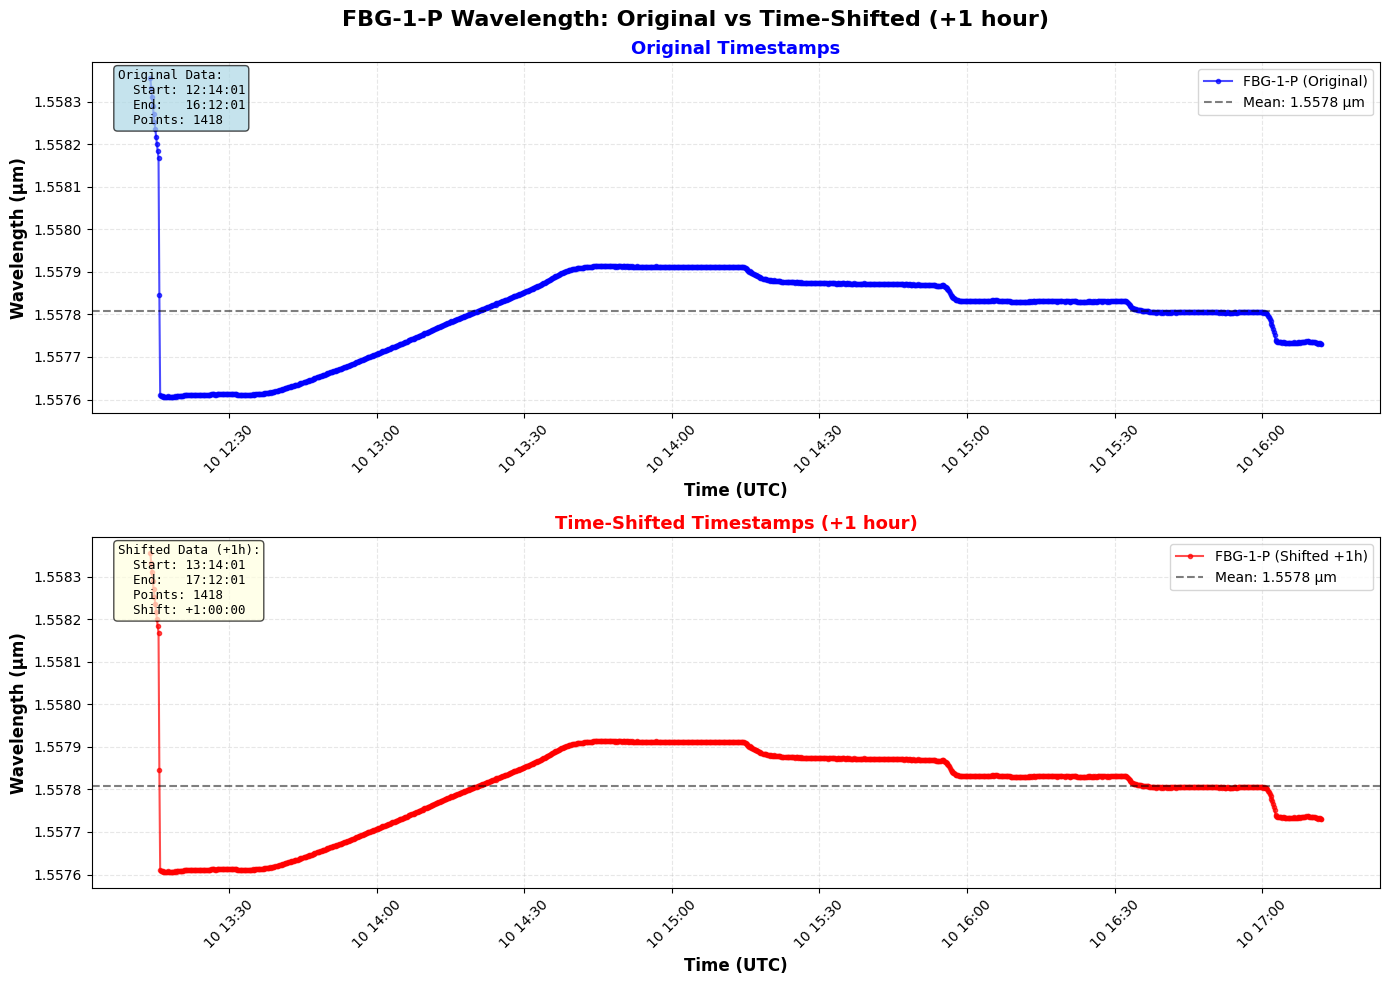

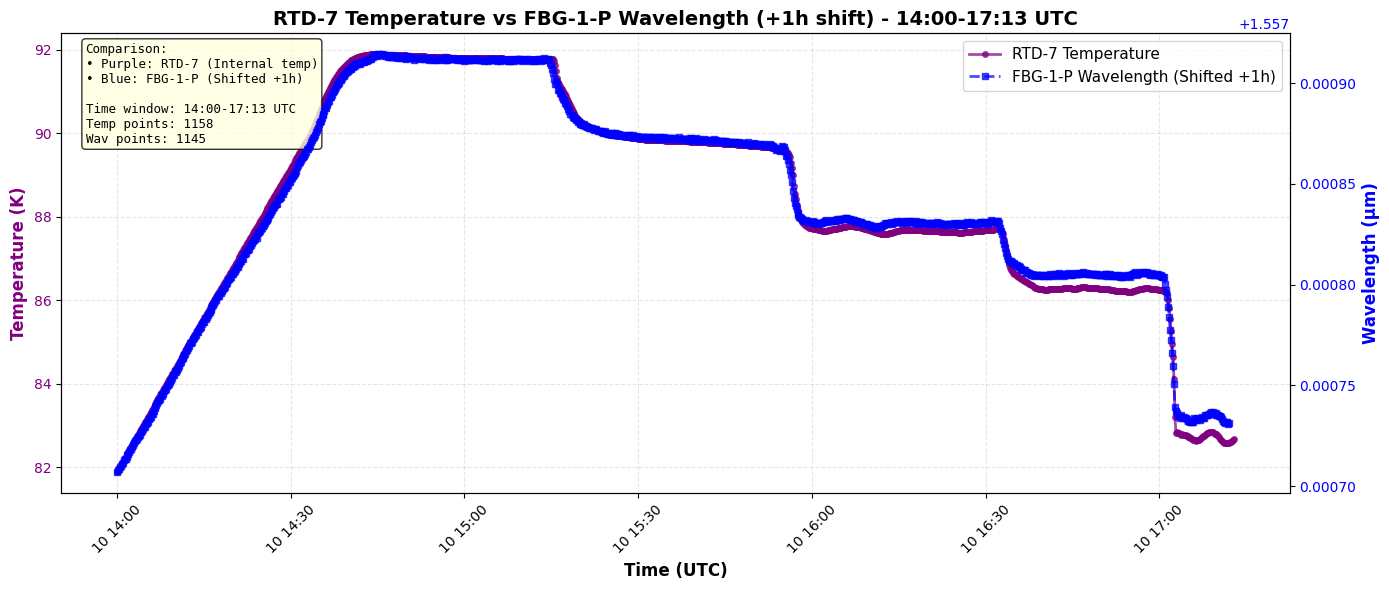


✅ Temporal shift visualization complete!
   All FBG sensors now have timestamps shifted by +1:00:00
   Shifted data stored in 'filtered_data_shifted' dictionary


In [5]:
# ============================================================================
# Temporal Shift Analysis: Apply +1 hour correction to FBG Wavelength Data
# ============================================================================
# Apply temporal shift of +1 hour to all filtered wavelength data
# This corrects for potential time synchronization issues between sensors

import datetime

print("=" * 80)
print("TEMPORAL SHIFT: Adding +1 hour to FBG Wavelength Timestamps")
print("=" * 80)

# Create a copy of filtered data with time shift applied
filtered_data_shifted = {}

# Apply +1 hour shift to all FBG sensors
time_shift = datetime.timedelta(hours=1)

for cfg in fbg_config:
    label = cfg["label"]
    
    # Get original filtered data
    original_data = filtered_data[label]
    
    # Apply time shift: ADD 1 hour to timestamps
    timestamps_shifted = original_data["timestamps"] + time_shift
    
    # Store shifted data
    filtered_data_shifted[label] = {
        "timestamps": timestamps_shifted,
        "wavelength": original_data["wavelength"],
        "mean": original_data["mean"],
        "std": original_data["std"],
        "threshold_min": original_data["threshold_min"],
        "threshold_max": original_data["threshold_max"],
        "n_valid": original_data["n_valid"],
        "n_total": original_data["n_total"]
    }
    
    # Show time shift for first and last point
    if label == "FBG-1-P":
        print(f"\n{label} - Time Shift Applied:")
        print(f"  Original first timestamp:  {original_data['timestamps'][0]}")
        print(f"  Shifted first timestamp:   {timestamps_shifted[0]}")
        print(f"  Time difference: +{time_shift}")
        print(f"  Original last timestamp:   {original_data['timestamps'][-1]}")
        print(f"  Shifted last timestamp:    {timestamps_shifted[-1]}")

print("\n" + "=" * 80)
print("✅ Time shift (+1 hour) applied to all FBG sensors")
print("=" * 80)

# ============================================================================
# VISUALIZATION: Compare Original vs Shifted timestamps for FBG-1-P
# ============================================================================

label_compare = "FBG-1-P"
data_original = filtered_data[label_compare]
data_shifted = filtered_data_shifted[label_compare]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
fig.suptitle('FBG-1-P Wavelength: Original vs Time-Shifted (+1 hour)', 
             fontsize=16, fontweight='bold')

# ============================================================================
# Subplot 1: Original timestamps
# ============================================================================

ax1.plot(data_original["timestamps"], data_original["wavelength"] * 1e6, 
         marker='o', markersize=3, linestyle='-', linewidth=1.5,
         color='blue', alpha=0.7, label='FBG-1-P (Original)')

# Add mean line
ax1.axhline(y=data_original["mean"] * 1e6, color='black', linestyle='--', 
            linewidth=1.5, alpha=0.5, label=f'Mean: {data_original["mean"]*1e6:.4f} μm')

ax1.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Wavelength (μm)', fontsize=12, fontweight='bold')
ax1.set_title('Original Timestamps', fontsize=13, fontweight='bold', color='blue')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Add info box
info_original = (f'Original Data:\n'
                 f'  Start: {data_original["timestamps"][0].strftime("%H:%M:%S")}\n'
                 f'  End:   {data_original["timestamps"][-1].strftime("%H:%M:%S")}\n'
                 f'  Points: {len(data_original["timestamps"])}')
ax1.text(0.02, 0.98, info_original, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ============================================================================
# Subplot 2: Shifted timestamps (+1 hour)
# ============================================================================

ax2.plot(data_shifted["timestamps"], data_shifted["wavelength"] * 1e6, 
         marker='o', markersize=3, linestyle='-', linewidth=1.5,
         color='red', alpha=0.7, label='FBG-1-P (Shifted +1h)')

# Add mean line
ax2.axhline(y=data_shifted["mean"] * 1e6, color='black', linestyle='--', 
            linewidth=1.5, alpha=0.5, label=f'Mean: {data_shifted["mean"]*1e6:.4f} μm')

ax2.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wavelength (μm)', fontsize=12, fontweight='bold')
ax2.set_title('Time-Shifted Timestamps (+1 hour)', fontsize=13, fontweight='bold', color='red')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

# Add info box
info_shifted = (f'Shifted Data (+1h):\n'
                f'  Start: {data_shifted["timestamps"][0].strftime("%H:%M:%S")}\n'
                f'  End:   {data_shifted["timestamps"][-1].strftime("%H:%M:%S")}\n'
                f'  Points: {len(data_shifted["timestamps"])}\n'
                f'  Shift: +1:00:00')
ax2.text(0.02, 0.98, info_shifted, transform=ax2.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Overlay comparison - RTD-7 Temperature vs FBG-1-P Shifted
# ============================================================================

# Select a time window to show the comparison
time_window_start = datetime.time(14, 0)
time_window_end = datetime.time(17, 13)

# Filter RTD-7 temperature data for window
sensor_id_temp = 6  # RTD-7
mask_temp = np.array([time_window_start <= t.time() <= time_window_end 
                      for t in timestamps_filtered])
timestamps_temp_window = timestamps_filtered[mask_temp]
temp_window_plot = temp_filtered[mask_temp, sensor_id_temp]

# Filter shifted wavelength data for window
mask_shift = np.array([time_window_start <= t.time() <= time_window_end 
                       for t in data_shifted["timestamps"]])
timestamps_shift_window = data_shifted["timestamps"][mask_shift]
wav_shift_window = data_shifted["wavelength"][mask_shift]

fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

# Plot temperature on primary y-axis
color_temp = 'purple'
ax1.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Temperature (K)', fontsize=12, fontweight='bold', color=color_temp)
ax1.plot(timestamps_temp_window, temp_window_plot, 
         marker='o', markersize=4, linestyle='-', linewidth=2,
         color=color_temp, alpha=0.7, label='RTD-7 Temperature')
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, linestyle='--')

# Create secondary y-axis for wavelength
ax2 = ax1.twinx()
color_wav = 'blue'
ax2.set_ylabel('Wavelength (μm)', fontsize=12, fontweight='bold', color=color_wav)
ax2.plot(timestamps_shift_window, wav_shift_window * 1e6, 
         marker='s', markersize=4, linestyle='--', linewidth=2,
         color=color_wav, alpha=0.7, label='FBG-1-P Wavelength (Shifted +1h)')
ax2.tick_params(axis='y', labelcolor=color_wav)

# Add title
ax1.set_title(f'RTD-7 Temperature vs FBG-1-P Wavelength (+1h shift) - {time_window_start.strftime("%H:%M")}-{time_window_end.strftime("%H:%M")} UTC', 
              fontsize=14, fontweight='bold')

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=11)

# Add info box
info_text = (f'Comparison:\n'
             f'• Purple: RTD-7 (Internal temp)\n'
             f'• Blue: FBG-1-P (Shifted +1h)\n'
             f'\nTime window: {time_window_start.strftime("%H:%M")}-{time_window_end.strftime("%H:%M")} UTC\n'
             f'Temp points: {len(temp_window_plot)}\n'
             f'Wav points: {len(wav_shift_window)}')
ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n✅ Temporal shift visualization complete!")
print(f"   All FBG sensors now have timestamps shifted by +{time_shift}")
print(f"   Shifted data stored in 'filtered_data_shifted' dictionary")


PLATEAU ANALYSIS - Mean Values for Defined Time Windows

Plateau Definitions:
--------------------------------------------------------------------------------
Plateau 1: 14:50 - 15:13 UTC
Plateau 2: 15:30 - 15:52 UTC
Plateau 3: 16:05 - 16:30 UTC
Plateau 4: 16:40 - 16:57 UTC
Plateau 5: 17:06 - 17:12 UTC

Plateau 1: 14:50 - 15:13 UTC
--------------------------------------------------------------------------------

1. FBG Wavelength Sensors:
   FBG-1-P     : λ = 1557911.76 pm  ±0.45 pm  (138 points)
   FBG-1-S     : λ = 1557910.56 pm  ±0.45 pm  (138 points)
   FBG-2-P     : λ = 1560996.52 pm  ±0.61 pm  (138 points)
   FBG-2-S     : λ = 1560995.96 pm  ±0.53 pm  (136 points)
   FBG-3-P     : λ = 1563969.10 pm  ±0.55 pm  (136 points)
   FBG-3-S     : λ = 1563969.24 pm  ±0.55 pm  (137 points)

2. RTD Temperature Sensors:
   RTD-1       : μ = 91.945 K  ±0.0164 K  (138 points)
   RTD-2       : μ = 91.817 K  ±0.0146 K  (138 points)
   RTD-3       : μ = 91.854 K  ±0.2350 K  (138 points)
   RTD-4 

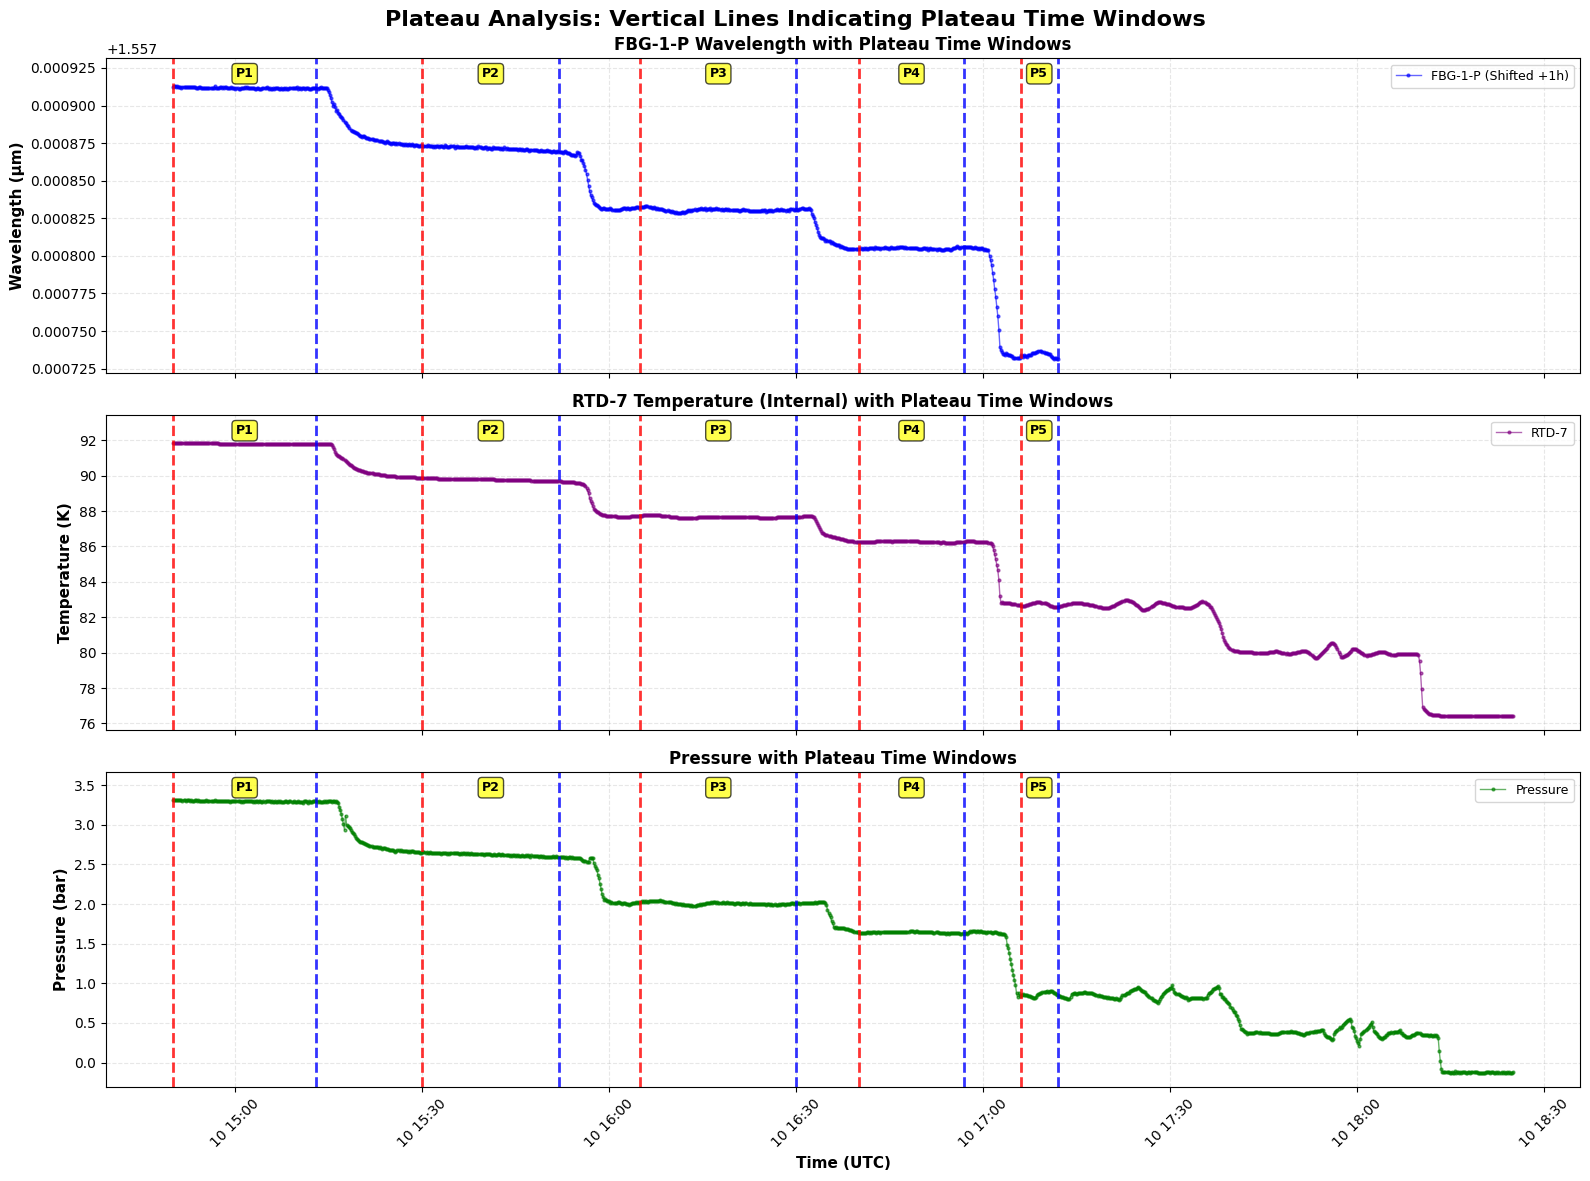


✅ Plateau visualization complete!
   Red vertical lines indicate plateau START times
   Blue vertical lines indicate plateau END times
   P1-P5 labels mark each plateau region
   Experiment date: 2025-03-10
   Visualization starts from: 14:50 UTC

Note:
   - FBG-1-P wavelength is shown with +1h shift applied
   - RTD-7 is the internal temperature sensor
   - All data filtered (≤0 removed, μ±3σ outliers removed)


In [10]:
# ============================================================================
# Plateau Analysis: Calculate Mean Values for Defined Time Windows
# ============================================================================
# Define pressure plateaus and calculate mean wavelength, temperature, and pressure
# for each interval using already filtered data

import datetime

print("=" * 80)
print("PLATEAU ANALYSIS - Mean Values for Defined Time Windows")
print("=" * 80)

# Define plateau time windows
plateaus = {
    "Plateau 1": {
        "start": datetime.time(14, 50),  # 14:50 UTC
        "end": datetime.time(15, 13)      # 15:13 UTC
    },
    "Plateau 2": {
        "start": datetime.time(15, 30),  # 15:30 UTC
        "end": datetime.time(15, 52)     # 15:52 UTC
    },
    "Plateau 3": {
        "start": datetime.time(16, 5),   # 16:05 UTC
        "end": datetime.time(16, 30)     # 16:30 UTC
    },
    "Plateau 4": {
        "start": datetime.time(16, 40),  # 16:40 UTC
        "end": datetime.time(16, 57)      # 16:57 UTC
    },
    "Plateau 5": {
        "start": datetime.time(17, 6),   # 17:06 UTC
        "end": datetime.time(17, 12)     # 17:12 UTC
    }
}

# Print plateau definitions
print("\nPlateau Definitions:")
print("-" * 80)
for plateau_name, times in plateaus.items():
    print(f"{plateau_name}: {times['start'].strftime('%H:%M')} - {times['end'].strftime('%H:%M')} UTC")
print("=" * 80)

# ============================================================================
# Calculate mean values for each plateau
# ============================================================================

plateau_results = {}

for plateau_name, times in plateaus.items():
    print(f"\n{plateau_name}: {times['start'].strftime('%H:%M')} - {times['end'].strftime('%H:%M')} UTC")
    print("-" * 80)
    
    plateau_results[plateau_name] = {
        "time_start": times["start"],
        "time_end": times["end"],
        "wavelength": {},  # Mean wavelength for each FBG sensor/polarization
        "temperature": {},  # Mean temperature for each RTD sensor
        "pressure": None,   # Mean pressure
        "n_points": {}      # Number of points in each dataset
    }
    
    # ========================================================================
    # 1. FBG Wavelength - Calculate mean for each sensor/polarization
    # ========================================================================
    
    print("\n1. FBG Wavelength Sensors:")
    for cfg in fbg_config:
        label = cfg["label"]
        
        # Use shifted data if available, otherwise use original filtered data
        if label in filtered_data_shifted:
            data_source = filtered_data_shifted[label]
            data_label = f"{label} (shifted +1h)"
        else:
            data_source = filtered_data[label]
            data_label = label
        
        # Apply time window mask
        mask_window = np.array([times["start"] <= t.time() <= times["end"] 
                                for t in data_source["timestamps"]])
        
        wav_window = data_source["wavelength"][mask_window]
        
        if len(wav_window) > 0:
            mean_wav = np.mean(wav_window)
            std_wav = np.std(wav_window)
            
            plateau_results[plateau_name]["wavelength"][label] = {
                "mean": mean_wav,
                "std": std_wav,
                "n_points": len(wav_window)
            }
            
            print(f"   {label:<12}: λ = {mean_wav*1e12:.2f} pm  ±{std_wav*1e12:.2f} pm  ({len(wav_window)} points)")
        else:
            plateau_results[plateau_name]["wavelength"][label] = {
                "mean": np.nan,
                "std": np.nan,
                "n_points": 0
            }
            print(f"   {label:<12}: No data in window")
    
    # ========================================================================
    # 2. RTD Temperature - Calculate mean for each sensor
    # ========================================================================
    
    print("\n2. RTD Temperature Sensors:")
    
    # Apply time window mask to temperature data
    mask_temp_window = np.array([times["start"] <= t.time() <= times["end"] 
                                 for t in timestamps_filtered])
    
    temp_window = temp_filtered[mask_temp_window]
    
    if len(temp_window) > 0:
        for cfg in rtd_config:
            sensor_id = cfg["id"]
            label = cfg["label"]
            
            temp_sensor_window = temp_window[:, sensor_id]
            
            mean_temp = np.mean(temp_sensor_window)
            std_temp = np.std(temp_sensor_window)
            
            plateau_results[plateau_name]["temperature"][label] = {
                "mean": mean_temp,
                "std": std_temp,
                "n_points": len(temp_sensor_window)
            }
            
            print(f"   {label:<12}: μ = {mean_temp:.3f} K  ±{std_temp:.4f} K  ({len(temp_sensor_window)} points)")
    else:
        for cfg in rtd_config:
            label = cfg["label"]
            plateau_results[plateau_name]["temperature"][label] = {
                "mean": np.nan,
                "std": np.nan,
                "n_points": 0
            }
        print(f"   No temperature data in window")
    
    # ========================================================================
    # 3. Pressure - Calculate mean
    # ========================================================================
    
    print("\n3. Pressure:")
    
    # Apply time window mask to pressure data
    mask_press_window = np.array([times["start"] <= t.time() <= times["end"] 
                                  for t in timestamps])
    
    press_window = press[mask_press_window]
    
    if len(press_window) > 0:
        mean_press = np.mean(press_window)
        std_press = np.std(press_window)
        
        plateau_results[plateau_name]["pressure"] = {
            "mean": mean_press,
            "std": std_press,
            "n_points": len(press_window)
        }
        
        print(f"   Pressure:     μ = {mean_press:.2f} bar  ±{std_press:.4f} bar  ({len(press_window)} points)")
    else:
        plateau_results[plateau_name]["pressure"] = {
            "mean": np.nan,
            "std": np.nan,
            "n_points": 0
        }
        print(f"   No pressure data in window")

print("\n" + "=" * 80)
print("✅ Plateau analysis complete!")
print("=" * 80)

# ============================================================================
# SUMMARY TABLE: All Plateaus
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY TABLE: Mean Values Across All Plateaus")
print("=" * 80)

# FBG Wavelength Summary
print("\nFBG Wavelength (μm):")
print("-" * 80)
header = f"{'Sensor':<12}"
for plateau_name in plateaus.keys():
    header += f"{plateau_name:<20}"
print(header)
print("-" * 80)

for cfg in fbg_config:
    label = cfg["label"]
    row = f"{label:<12}"
    for plateau_name in plateaus.keys():
        mean_wav = plateau_results[plateau_name]["wavelength"][label]["mean"]
        if not np.isnan(mean_wav):
            row += f"{mean_wav*1e6:<20.4f}"
        else:
            row += f"{'N/A':<20}"
    print(row)

# RTD Temperature Summary
print("\n" + "-" * 80)
print("RTD Temperature (K):")
print("-" * 80)
header = f"{'Sensor':<12}"
for plateau_name in plateaus.keys():
    header += f"{plateau_name:<20}"
print(header)
print("-" * 80)

for cfg in rtd_config:
    label = cfg["label"]
    row = f"{label:<12}"
    for plateau_name in plateaus.keys():
        mean_temp = plateau_results[plateau_name]["temperature"][label]["mean"]
        if not np.isnan(mean_temp):
            row += f"{mean_temp:<20.3f}"
        else:
            row += f"{'N/A':<20}"
    print(row)

# Pressure Summary
print("\n" + "-" * 80)
print("Pressure (bar):")
print("-" * 80)
header = f"{'Sensor':<12}"
for plateau_name in plateaus.keys():
    header += f"{plateau_name:<20}"
print(header)
print("-" * 80)

row = f"{'Pressure':<12}"
for plateau_name in plateaus.keys():
    mean_press = plateau_results[plateau_name]["pressure"]["mean"]
    if not np.isnan(mean_press):
        row += f"{mean_press:<20.2f}"
    else:
        row += f"{'N/A':<20}"
print(row)

print("=" * 80)

# ============================================================================
# VISUALIZATION: Plateau Time Windows with Vertical Lines
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Plateau Analysis: Vertical Lines Indicating Plateau Time Windows', 
             fontsize=16, fontweight='bold')

# Get experiment date from first timestamp
experiment_date = timestamps[0].date()

# Define time range starting from first plateau (automatically uses first plateau start time)
first_plateau_start = list(plateaus.values())[0]["start"]
time_filter_start = datetime.datetime.combine(experiment_date, first_plateau_start)

# ============================================================================
# Subplot 1: FBG-1-P Wavelength (Shifted +1h) with plateau boundaries
# ============================================================================

label_plot = "FBG-1-P"
if label_plot in filtered_data_shifted:
    data_plot = filtered_data_shifted[label_plot]
    title_suffix = "(Shifted +1h)"
else:
    data_plot = filtered_data[label_plot]
    title_suffix = ""

# Filter data to start from first plateau
mask_plot_wav = data_plot["timestamps"] >= time_filter_start
timestamps_plot_wav = data_plot["timestamps"][mask_plot_wav]
wavelength_plot_wav = data_plot["wavelength"][mask_plot_wav]

axes[0].plot(timestamps_plot_wav, wavelength_plot_wav * 1e6,
             marker='o', markersize=2, linestyle='-', linewidth=1,
             color='blue', alpha=0.6, label=f'{label_plot} {title_suffix}')

# Store y-limits before adding annotations
y_min_0, y_max_0 = np.min(wavelength_plot_wav * 1e6), np.max(wavelength_plot_wav * 1e6)
y_range_0 = y_max_0 - y_min_0

# Plot vertical lines for plateau boundaries
for idx, (plateau_name, results) in enumerate(plateau_results.items()):
    # Create datetime objects with correct experiment date
    start_dt = datetime.datetime.combine(experiment_date, results["time_start"])
    end_dt = datetime.datetime.combine(experiment_date, results["time_end"])
    
    # Plot vertical lines for start (red) and end (blue)
    axes[0].axvline(x=start_dt, color='red', linestyle='--', linewidth=2, alpha=0.8)
    axes[0].axvline(x=end_dt, color='blue', linestyle='--', linewidth=2, alpha=0.8)
    
    # Add label using fixed position from data range
    mid_dt = start_dt + (end_dt - start_dt) / 2
    label_y_pos = y_max_0 + 0.02 * y_range_0
    axes[0].text(mid_dt, label_y_pos, f'P{idx+1}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0].set_ylabel('Wavelength (μm)', fontsize=11, fontweight='bold')
axes[0].set_title(f'{label_plot} Wavelength with Plateau Time Windows', 
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')
# Set y-limits with some margin for labels
axes[0].set_ylim(y_min_0 - 0.05 * y_range_0, y_max_0 + 0.1 * y_range_0)

# ============================================================================
# Subplot 2: RTD-7 Temperature (Internal sensor) with plateau boundaries
# ============================================================================

sensor_id_plot = 6  # RTD-7 (internal sensor)
label_temp = "RTD-7"

# Filter temperature data to start from first plateau
mask_plot_temp = timestamps_filtered >= time_filter_start
timestamps_plot_temp = timestamps_filtered[mask_plot_temp]
temp_plot_temp = temp_filtered[mask_plot_temp, sensor_id_plot]

axes[1].plot(timestamps_plot_temp, temp_plot_temp,
             marker='o', markersize=2, linestyle='-', linewidth=1,
             color='purple', alpha=0.6, label=label_temp)

# Store y-limits before adding annotations
y_min_1, y_max_1 = np.min(temp_plot_temp), np.max(temp_plot_temp)
y_range_1 = y_max_1 - y_min_1

# Plot vertical lines for plateau boundaries
for idx, (plateau_name, results) in enumerate(plateau_results.items()):
    # Create datetime objects with correct experiment date
    start_dt = datetime.datetime.combine(experiment_date, results["time_start"])
    end_dt = datetime.datetime.combine(experiment_date, results["time_end"])
    
    # Plot vertical lines for start (red) and end (blue)
    axes[1].axvline(x=start_dt, color='red', linestyle='--', linewidth=2, alpha=0.8)
    axes[1].axvline(x=end_dt, color='blue', linestyle='--', linewidth=2, alpha=0.8)
    
    # Add label using fixed position from data range
    mid_dt = start_dt + (end_dt - start_dt) / 2
    label_y_pos = y_max_1 + 0.02 * y_range_1
    axes[1].text(mid_dt, label_y_pos, f'P{idx+1}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[1].set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
axes[1].set_title(f'{label_temp} Temperature (Internal) with Plateau Time Windows', 
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')
# Set y-limits with some margin for labels
axes[1].set_ylim(y_min_1 - 0.05 * y_range_1, y_max_1 + 0.1 * y_range_1)

# ============================================================================
# Subplot 3: Pressure with plateau boundaries
# ============================================================================

# Filter pressure data to start from first plateau
mask_plot_press = timestamps >= time_filter_start
timestamps_plot_press = timestamps[mask_plot_press]
press_plot = press[mask_plot_press]

axes[2].plot(timestamps_plot_press, press_plot,
             marker='o', markersize=2, linestyle='-', linewidth=1,
             color='green', alpha=0.6, label='Pressure')

# Store y-limits before adding annotations
y_min_2, y_max_2 = np.min(press_plot), np.max(press_plot)
y_range_2 = y_max_2 - y_min_2

# Plot vertical lines for plateau boundaries
for idx, (plateau_name, results) in enumerate(plateau_results.items()):
    # Create datetime objects with correct experiment date
    start_dt = datetime.datetime.combine(experiment_date, results["time_start"])
    end_dt = datetime.datetime.combine(experiment_date, results["time_end"])
    
    # Plot vertical lines for start (red) and end (blue)
    axes[2].axvline(x=start_dt, color='red', linestyle='--', linewidth=2, alpha=0.8)
    axes[2].axvline(x=end_dt, color='blue', linestyle='--', linewidth=2, alpha=0.8)
    
    # Add label using fixed position from data range
    mid_dt = start_dt + (end_dt - start_dt) / 2
    label_y_pos = y_max_2 + 0.02 * y_range_2
    axes[2].text(mid_dt, label_y_pos, f'P{idx+1}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[2].set_xlabel('Time (UTC)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Pressure (bar)', fontsize=11, fontweight='bold')
axes[2].set_title('Pressure with Plateau Time Windows', 
                  fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(loc='best', fontsize=9)
axes[2].grid(True, alpha=0.3, linestyle='--')
# Set y-limits with some margin for labels
axes[2].set_ylim(y_min_2 - 0.05 * y_range_2, y_max_2 + 0.1 * y_range_2)

plt.tight_layout()
plt.show()

print("\n✅ Plateau visualization complete!")
print("   Red vertical lines indicate plateau START times")
print("   Blue vertical lines indicate plateau END times")
print("   P1-P5 labels mark each plateau region")
print(f"   Experiment date: {experiment_date}")
print(f"   Visualization starts from: {first_plateau_start.strftime('%H:%M')} UTC")
print("\nNote:")
print("   - FBG-1-P wavelength is shown with +1h shift applied")
print("   - RTD-7 is the internal temperature sensor")
print("   - All data filtered (≤0 removed, μ±3σ outliers removed)")

THERMAL SENSITIVITY ANALYSIS - FBG-1-P vs RTD-7

Plateau 1:
  FBG-1-P: λ = 1557911.76 pm  ±0.45 pm
  RTD-7: T = 91.811 K  ±0.0219 K

Plateau 2:
  FBG-1-P: λ = 1557871.61 pm  ±1.17 pm
  RTD-7: T = 89.782 K  ±0.0530 K

Plateau 3:
  FBG-1-P: λ = 1557830.59 pm  ±0.94 pm
  RTD-7: T = 87.671 K  ±0.0486 K

Plateau 4:
  FBG-1-P: λ = 1557805.03 pm  ±0.55 pm
  RTD-7: T = 86.268 K  ±0.0298 K

Plateau 5:
  FBG-1-P: λ = 1557734.27 pm  ±1.58 pm
  RTD-7: T = 82.724 K  ±0.0911 K


LINEAR FIT RESULTS: λ(pm) = a + b*T(K)
Slope (b):        19.46 pm/K
Intercept (a):    1556124.55 pm
R² coefficient:   0.999867
P-value:          6.544697e-07
Std error:        0.1298 pm/K

📊 Creating sensitivity plot...


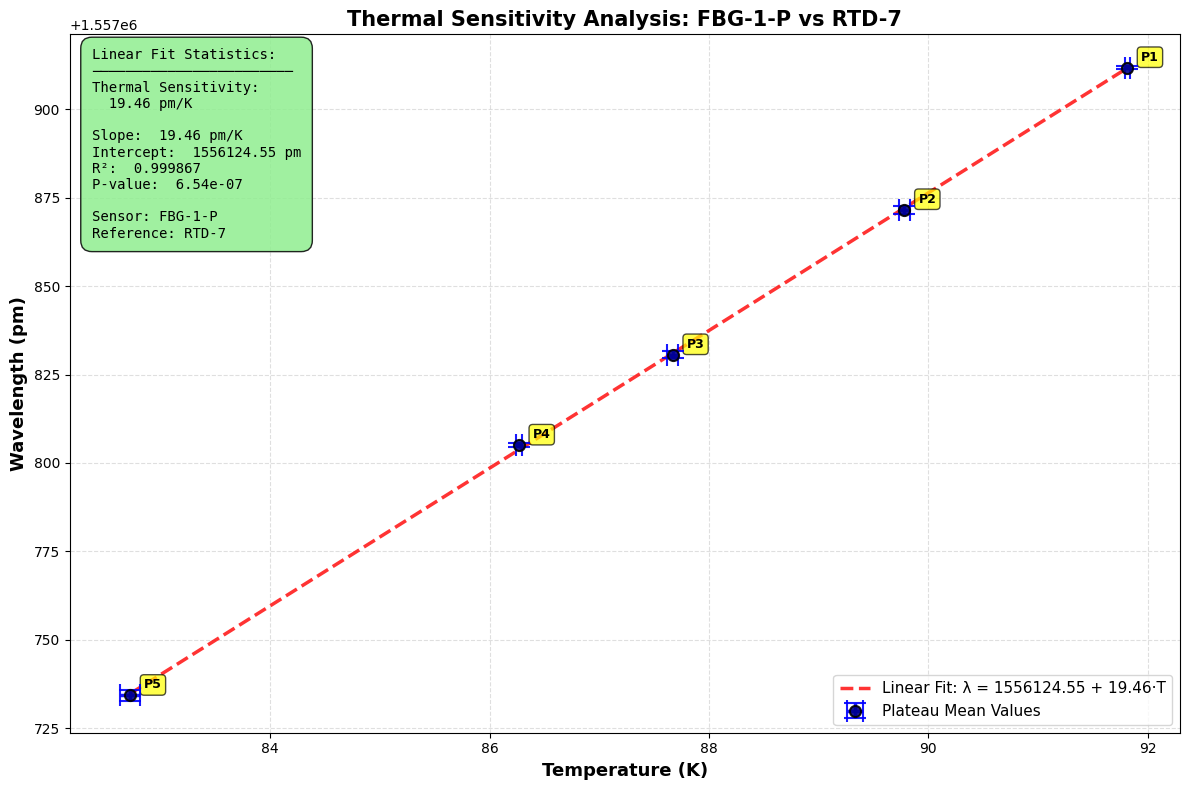


✅ Thermal sensitivity analysis complete!
   Sensitivity: 19.46 pm/K
   Expected range for PEEK-7: 19-20 pm/K
   Fit quality: R² = 0.999867

INDIVIDUAL SENSITIVITIES (Consecutive Plateaus)

Plateau 1 → Plateau 2:
  ΔT = -2.029 K
  Δλ = -40152611.83 pm
  Sensitivity = 19787875.43 pm/K

Plateau 2 → Plateau 3:
  ΔT = -2.111 K
  Δλ = -41016660.17 pm
  Sensitivity = 19425962.28 pm/K

Plateau 3 → Plateau 4:
  ΔT = -1.403 K
  Δλ = -25558401.05 pm
  Sensitivity = 18217976.34 pm/K

Plateau 4 → Plateau 5:
  ΔT = -3.543 K
  Δλ = -70763741.89 pm
  Sensitivity = 19970055.20 pm/K



In [13]:
# ============================================================================
# Temperature Sensitivity Analysis: FBG-1-P (Sensor 0,0)
# ============================================================================
# Calculate thermal sensitivity (Δλ/ΔT) from plateau mean values
# Compare FBG-1-P wavelength vs RTD-7 temperature

import numpy as np
from scipy import stats

print("=" * 80)
print("THERMAL SENSITIVITY ANALYSIS - FBG-1-P vs RTD-7")
print("=" * 80)

# Extract plateau mean values for FBG-1-P and RTD-7
sensor_label_wav = "FBG-1-P"  # Sensor 0,0 (sensor 0, polarization 0)
sensor_label_temp = "RTD-7"    # Internal temperature sensor

wavelength_means = []
wavelength_stds = []
temperature_means = []
temperature_stds = []
plateau_labels = []

for plateau_name, results in plateau_results.items():
    # Get wavelength data (in meters)
    wav_mean = results["wavelength"][sensor_label_wav]["mean"]
    wav_std = results["wavelength"][sensor_label_wav]["std"]
    
    # Get temperature data (in Kelvin)
    temp_mean = results["temperature"][sensor_label_temp]["mean"]
    temp_std = results["temperature"][sensor_label_temp]["std"]
    
    # Store values in pm for consistency
    wavelength_means.append(wav_mean * 1e12)  # Convert to pm
    wavelength_stds.append(wav_std * 1e12)     # Convert to pm for error bars
    temperature_means.append(temp_mean)
    temperature_stds.append(temp_std)
    plateau_labels.append(plateau_name)
    
    print(f"\n{plateau_name}:")
    print(f"  {sensor_label_wav}: λ = {wav_mean*1e12:.2f} pm  ±{wav_std*1e12:.2f} pm")
    print(f"  {sensor_label_temp}: T = {temp_mean:.3f} K  ±{temp_std:.4f} K")

# Convert to numpy arrays
wavelength_means = np.array(wavelength_means)
wavelength_stds = np.array(wavelength_stds)
temperature_means = np.array(temperature_means)
temperature_stds = np.array(temperature_stds)

print("\n" + "=" * 80)

# ============================================================================
# Linear Fit: λ = a + b*T
# ============================================================================

# Perform linear regression (wavelength in pm, temperature in K)
slope, intercept, r_value, p_value, std_err = stats.linregress(temperature_means, wavelength_means)

# Calculate fitted values
temp_fit = np.linspace(temperature_means.min(), temperature_means.max(), 100)
wav_fit = slope * temp_fit + intercept

# Slope is already in pm/K since wavelength_means is in pm
slope_pm_per_K = slope

print("\n" + "=" * 80)
print("LINEAR FIT RESULTS: λ(pm) = a + b*T(K)")
print("=" * 80)
print(f"Slope (b):        {slope:.2f} pm/K")
print(f"Intercept (a):    {intercept:.2f} pm")
print(f"R² coefficient:   {r_value**2:.6f}")
print(f"P-value:          {p_value:.6e}")
print(f"Std error:        {std_err:.4f} pm/K")
print("=" * 80)

# ============================================================================
# VISUALIZATION: Wavelength vs Temperature with Linear Fit
# ============================================================================

print("\n📊 Creating sensitivity plot...")

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot plateau mean values with error bars (wavelength in pm, temperature in K)
ax.errorbar(temperature_means, wavelength_means, 
            xerr=temperature_stds, yerr=wavelength_stds,  # Both in their units (K and pm)
            fmt='o', markersize=8, capsize=8, capthick=2.5, elinewidth=2.5,
            color='darkblue', markeredgecolor='black', markeredgewidth=1.5,
            ecolor='blue', alpha=0.9,
            label='Plateau Mean Values', zorder=5)

# Add labels for each plateau
for i, label in enumerate(plateau_labels):
    ax.annotate(label.replace("Plateau ", "P"), 
                (temperature_means[i], wavelength_means[i]),
                textcoords="offset points", xytext=(10, 5),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Plot linear fit
ax.plot(temp_fit, wav_fit, 'r--', linewidth=2.5, alpha=0.8,
        label=f'Linear Fit: λ = {intercept:.2f} + {slope:.2f}·T')

# Formatting
ax.set_xlabel('Temperature (K)', fontsize=13, fontweight='bold')
ax.set_ylabel('Wavelength (pm)', fontsize=13, fontweight='bold')
ax.set_title(f'Thermal Sensitivity Analysis: {sensor_label_wav} vs {sensor_label_temp}', 
             fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.4, linestyle='--')

# Add text box with fit statistics
fit_text = (f'Linear Fit Statistics:\n'
            f'────────────────────────\n'
            f'Thermal Sensitivity:\n'
            f'  {slope_pm_per_K:.2f} pm/K\n'
            f'\n'
            f'Slope:  {slope:.2f} pm/K\n'
            f'Intercept:  {intercept:.2f} pm\n'
            f'R²:  {r_value**2:.6f}\n'
            f'P-value:  {p_value:.2e}\n'
            f'\n'
            f'Sensor: {sensor_label_wav}\n'
            f'Reference: {sensor_label_temp}')
ax.text(0.02, 0.98, fit_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.85, pad=0.8))

plt.tight_layout()
plt.show()

print("\n✅ Thermal sensitivity analysis complete!")
print(f"   Sensitivity: {slope_pm_per_K:.2f} pm/K")
print(f"   Expected range for PEEK-7: 19-20 pm/K")
print(f"   Fit quality: R² = {r_value**2:.6f}")

# ============================================================================
# Calculate individual sensitivities between consecutive plateaus
# ============================================================================

print("\n" + "=" * 80)
print("INDIVIDUAL SENSITIVITIES (Consecutive Plateaus)")
print("=" * 80)

for i in range(len(plateau_labels) - 1):
    delta_wav = (wavelength_means[i+1] - wavelength_means[i]) * 1e6  # Convert to pm
    delta_temp = temperature_means[i+1] - temperature_means[i]
    
    if delta_temp != 0:
        sensitivity = delta_wav / delta_temp
        print(f"\n{plateau_labels[i]} → {plateau_labels[i+1]}:")
        print(f"  ΔT = {delta_temp:+.3f} K")
        print(f"  Δλ = {delta_wav:+.2f} pm")
        print(f"  Sensitivity = {sensitivity:.2f} pm/K")
    else:
        print(f"\n{plateau_labels[i]} → {plateau_labels[i+1]}:")
        print(f"  ΔT ≈ 0 K (no temperature change)")

print("\n" + "=" * 80)

COMPREHENSIVE THERMAL SENSITIVITY ANALYSIS
All FBG Sensors vs RTD-7 and RTD-8

REFERENCE SENSOR: RTD-7

FBG-1-P:
  Sensitivity:     19.46 pm/K
  R²:           0.999867
  P-value:      6.54e-07

FBG-1-S:
  Sensitivity:     19.38 pm/K
  R²:           0.999833
  P-value:      9.19e-07

FBG-2-P:
  Sensitivity:     19.88 pm/K
  R²:           0.999942
  P-value:      1.87e-07

FBG-2-S:
  Sensitivity:     19.92 pm/K
  R²:           0.999970
  P-value:      6.85e-08

FBG-3-P:
  Sensitivity:     19.55 pm/K
  R²:           0.999936
  P-value:      2.18e-07

FBG-3-S:
  Sensitivity:     19.59 pm/K
  R²:           0.999923
  P-value:      2.88e-07

REFERENCE SENSOR: RTD-8

FBG-1-P:
  Sensitivity:     19.46 pm/K
  R²:           0.999881
  P-value:      5.51e-07

FBG-1-S:
  Sensitivity:     19.37 pm/K
  R²:           0.999864
  P-value:      6.72e-07

FBG-2-P:
  Sensitivity:     19.88 pm/K
  R²:           0.999922
  P-value:      2.90e-07

FBG-2-S:
  Sensitivity:     19.91 pm/K
  R²:           0.9999

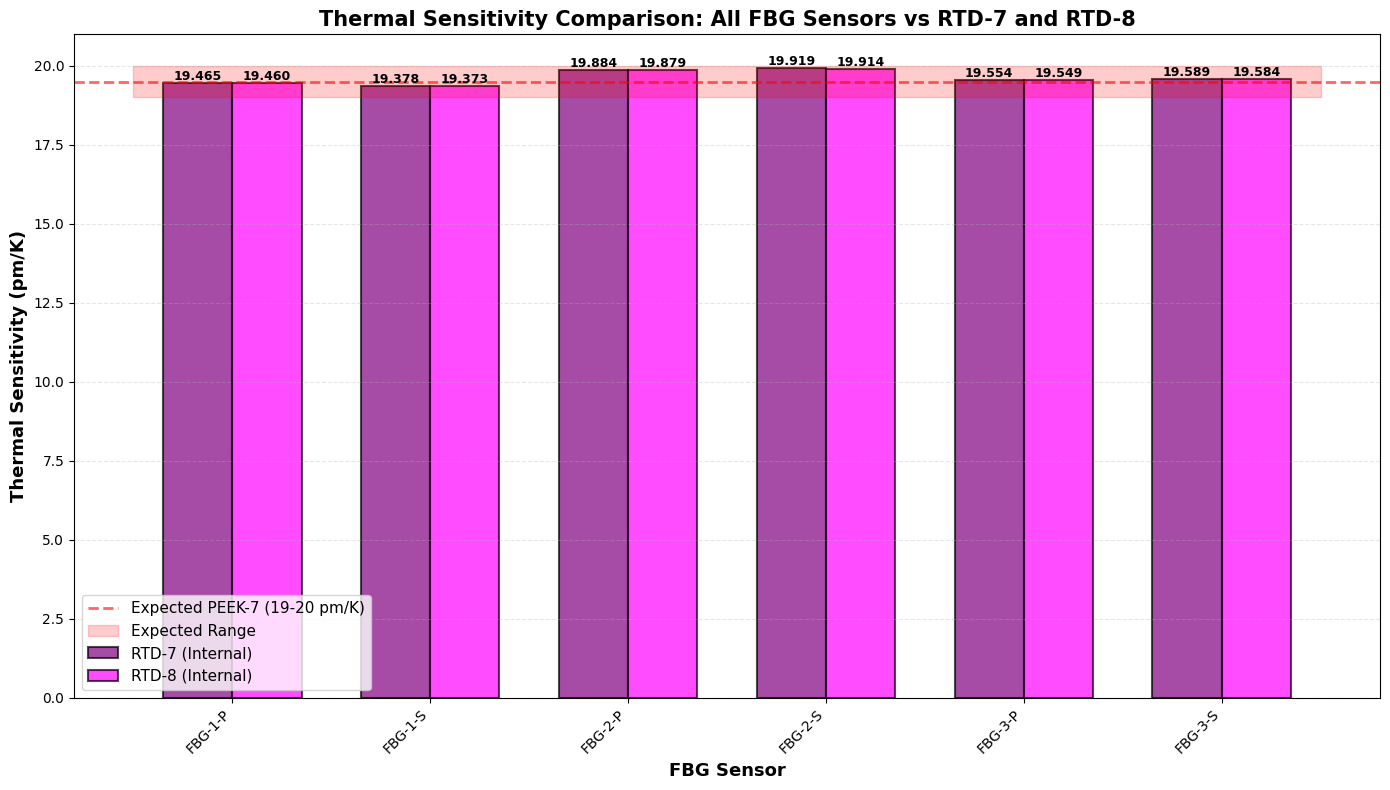


✅ Comprehensive sensitivity analysis complete!
   Total sensors analyzed: 6
   Temperature references: 2
   Total sensitivity calculations: 12


In [14]:
# ============================================================================
# Comprehensive Sensitivity Analysis: All FBG Sensors vs RTD-7 and RTD-8
# ============================================================================
# Calculate thermal sensitivity (Δλ/ΔT) for all FBG sensors/polarizations
# Compare with both internal temperature sensors (RTD-7 and RTD-8)

import numpy as np
from scipy import stats

print("=" * 80)
print("COMPREHENSIVE THERMAL SENSITIVITY ANALYSIS")
print("All FBG Sensors vs RTD-7 and RTD-8")
print("=" * 80)

# Reference temperature sensors
temp_sensors = ["RTD-7", "RTD-8"]

# Store all sensitivity results
sensitivity_results = {}

for temp_label in temp_sensors:
    print(f"\n{'='*80}")
    print(f"REFERENCE SENSOR: {temp_label}")
    print(f"{'='*80}")
    
    # Extract temperature means for this reference sensor
    temperature_means = []
    temperature_stds = []
    
    for plateau_name, results in plateau_results.items():
        temp_mean = results["temperature"][temp_label]["mean"]
        temp_std = results["temperature"][temp_label]["std"]
        temperature_means.append(temp_mean)
        temperature_stds.append(temp_std)
    
    temperature_means = np.array(temperature_means)
    temperature_stds = np.array(temperature_stds)
    
    # Analyze each FBG sensor/polarization
    for cfg in fbg_config:
        label = cfg["label"]
        
        # Extract wavelength means for this sensor
        wavelength_means = []
        wavelength_stds = []
        
        for plateau_name, results in plateau_results.items():
            wav_mean = results["wavelength"][label]["mean"]
            wav_std = results["wavelength"][label]["std"]
            wavelength_means.append(wav_mean * 1e6)  # Convert to μm
            wavelength_stds.append(wav_std * 1e9)     # Convert to nm
        
        wavelength_means = np.array(wavelength_means)
        wavelength_stds = np.array(wavelength_stds)
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            temperature_means, wavelength_means
        )
        
        # Convert slope to pm/K
        slope_pm_per_K = slope * 1e6  # μm/K to pm/K
        
        # Store results
        if label not in sensitivity_results:
            sensitivity_results[label] = {}
        
        sensitivity_results[label][temp_label] = {
            "slope_pm_K": slope_pm_per_K,
            "slope_um_K": slope,
            "intercept": intercept,
            "r_squared": r_value**2,
            "p_value": p_value,
            "std_err": std_err
        }
        
        print(f"\n{label}:")
        print(f"  Sensitivity:  {slope_pm_per_K:>8.2f} pm/K")
        print(f"  R²:           {r_value**2:>8.6f}")
        print(f"  P-value:      {p_value:>8.2e}")

print("\n" + "=" * 80)

# ============================================================================
# Create Summary Table
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY SUMMARY TABLE")
print("=" * 80)

# Print table header
header = f"{'FBG Sensor':<12} {'Pol':<4} {'S#':<3} {'RTD-7 (pm/K)':<15} {'RTD-7 R²':<12} {'RTD-8 (pm/K)':<15} {'RTD-8 R²':<12}"
print("\n" + header)
print("-" * 80)

# Print data rows
for cfg in fbg_config:
    label = cfg["label"]
    pol_name = "P" if cfg["pol"] == 0 else "S"
    sensor_num = cfg["sensor"] + 1
    
    # Get RTD-7 data
    if label in sensitivity_results and "RTD-7" in sensitivity_results[label]:
        rtd7_data = sensitivity_results[label]["RTD-7"]
        rtd7_sens = f"{rtd7_data['slope_pm_K']:.2f}"
        rtd7_r2 = f"{rtd7_data['r_squared']:.4f}"
    else:
        rtd7_sens = "N/A"
        rtd7_r2 = "N/A"
    
    # Get RTD-8 data
    if label in sensitivity_results and "RTD-8" in sensitivity_results[label]:
        rtd8_data = sensitivity_results[label]["RTD-8"]
        rtd8_sens = f"{rtd8_data['slope_pm_K']:.2f}"
        rtd8_r2 = f"{rtd8_data['r_squared']:.4f}"
    else:
        rtd8_sens = "N/A"
        rtd8_r2 = "N/A"
    
    # Print row
    row = f"{label:<12} {pol_name:<4} {sensor_num:<3} {rtd7_sens:<15} {rtd7_r2:<12} {rtd8_sens:<15} {rtd8_r2:<12}"
    print(row)

print("-" * 80)
print("=" * 80)

# ============================================================================
# Statistical Summary
# ============================================================================

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

for temp_label in temp_sensors:
    sensitivities = [
        sensitivity_results[cfg["label"]][temp_label]["slope_pm_K"]
        for cfg in fbg_config
        if cfg["label"] in sensitivity_results and temp_label in sensitivity_results[cfg["label"]]
    ]
    
    if len(sensitivities) > 0:
        mean_sens = np.mean(sensitivities)
        std_sens = np.std(sensitivities)
        min_sens = np.min(sensitivities)
        max_sens = np.max(sensitivities)
        
        print(f"\n{temp_label} Reference:")
        print(f"  Mean sensitivity:     {mean_sens:.2f} pm/K")
        print(f"  Std deviation:        {std_sens:.2f} pm/K")
        print(f"  Min sensitivity:      {min_sens:.2f} pm/K")
        print(f"  Max sensitivity:      {max_sens:.2f} pm/K")
        print(f"  Range:                {max_sens - min_sens:.2f} pm/K")

print("\n" + "=" * 80)
print("Expected PEEK-7 sensitivity: 19-20 pm/K")
print("=" * 80)

# ============================================================================
# Comparison Plot: RTD-7 vs RTD-8
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

x_positions = np.arange(len(fbg_config))
bar_width = 0.35

# Extract sensitivities for plotting
rtd7_sensitivities = [
    sensitivity_results[cfg["label"]]["RTD-7"]["slope_pm_K"]
    for cfg in fbg_config
]
rtd8_sensitivities = [
    sensitivity_results[cfg["label"]]["RTD-8"]["slope_pm_K"]
    for cfg in fbg_config
]

# Create bars
bars1 = ax.bar(x_positions - bar_width/2, rtd7_sensitivities, bar_width,
               label='RTD-7 (Internal)', color='purple', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_positions + bar_width/2, rtd8_sensitivities, bar_width,
               label='RTD-8 (Internal)', color='magenta', alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars with more decimals
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add reference line for expected PEEK-7 sensitivity
ax.axhline(y=19.5, color='red', linestyle='--', linewidth=2, alpha=0.6, 
           label='Expected PEEK-7 (19-20 pm/K)')
ax.fill_between([-0.5, len(fbg_config)-0.5], 19, 20, 
                alpha=0.2, color='red', label='Expected Range')

# Formatting
ax.set_xlabel('FBG Sensor', fontsize=13, fontweight='bold')
ax.set_ylabel('Thermal Sensitivity (pm/K)', fontsize=13, fontweight='bold')
ax.set_title('Thermal Sensitivity Comparison: All FBG Sensors vs RTD-7 and RTD-8', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels([cfg["label"] for cfg in fbg_config], rotation=45, ha='right')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

print("\n✅ Comprehensive sensitivity analysis complete!")
print(f"   Total sensors analyzed: {len(fbg_config)}")
print(f"   Temperature references: {len(temp_sensors)}")
print(f"   Total sensitivity calculations: {len(fbg_config) * len(temp_sensors)}")
